In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Libraries + Python setup
project_dir <- "/content/drive/MyDrive/Egcompbio/glioblastomamofa"

.libPaths("/content/drive/MyDrive/Colab Notebooks/R_lib")

pkgs <- c("tidyverse","limma","impute","ggrepel","factoextra","cluster",
          "gridExtra","corrplot","RColorBrewer","survival","survminer",
          "reshape2","data.table","reticulate")
for (p in pkgs) if (!requireNamespace(p, quietly = TRUE)) install.packages(p)

if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")
BiocManager::install(c("limma","impute","MOFA2","org.Hs.eg.db"), update = FALSE, ask = FALSE)

library(tidyverse); library(limma); library(impute); library(ggrepel)
library(factoextra); library(cluster); library(survival); library(survminer)
library(org.Hs.eg.db); library(AnnotationDbi)
library(MOFA2); library(reticulate)

py_require("mofapy2")   # the ONLY Python setup line needed

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'limma' 'impute' 'MOFA2' 'org.Hs.eg.db'”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Welcome to factoextra!

Want to learn more?

In [ ]:
#Load the 5 omics files + metadata + survival
setwd(project_dir)

rna   <- read.delim("GBM_RNAseq_gene_RSEM_coding_UQ_1500_log2_Tumor.txt", row.names = 1, check.names = FALSE)
prot  <- read.delim("GBM_proteomics_gene_abundance_log2_reference_intensity_normalized_Tumor.txt", row.names = 1, check.names = FALSE)
meth  <- read.delim("GBM_methylation_gene_beta_value_Tumor.txt", row.names = 1, check.names = FALSE)
mirna <- read.delim("GBM_miRNAseq_mature_miRNA_RPM_log2_Tumor.txt", row.names = 1, check.names = FALSE)
mut   <- read.delim("GBM_somatic_mutation_gene_level_binary.txt", row.names = 1, check.names = FALSE)

dim(rna); dim(prot); dim(meth); dim(mirna); dim(mut)

meta_raw <- read.delim("GBM_meta.txt", check.names = FALSE, stringsAsFactors = FALSE)
meta <- meta_raw[meta_raw$case_id != "data_type", ]   # drop the column-type descriptor row
rownames(meta) <- meta$case_id

surv <- read.delim("GBM_survival.txt", check.names = FALSE)
rownames(surv) <- surv$case_id

[1] 60669    99

[1] 12100    99

[1] 13178    97

[1] 2582   98

[1] 4626   99

In [ ]:
#Map Ensembl IDs to gene symbols
map_to_symbol <- function(mat) {
  ensembl_noversion <- sub("\\..*$", "", rownames(mat))
  symbol <- mapIds(org.Hs.eg.db, keys = ensembl_noversion,
                    keytype = "ENSEMBL", column = "SYMBOL", multiVals = "first")
  keep <- !is.na(symbol) & !duplicated(symbol)
  mat <- mat[keep, ]
  rownames(mat) <- symbol[keep]
  cat("  kept", nrow(mat), "of", length(keep), "features with an unambiguous gene symbol\n")
  mat
}

rna  <- map_to_symbol(rna)
prot <- map_to_symbol(prot)
meth <- map_to_symbol(meth)
mut  <- map_to_symbol(mut)

'select()' returned 1:many mapping between keys and columns



  kept 36629 of 60669 features with an unambiguous gene symbol


'select()' returned 1:many mapping between keys and columns



  kept 12081 of 12100 features with an unambiguous gene symbol


'select()' returned 1:many mapping between keys and columns



  kept 12893 of 13178 features with an unambiguous gene symbol


'select()' returned 1:many mapping between keys and columns



  kept 4614 of 4626 features with an unambiguous gene symbol



==== RNA-seq ====
Final: 32659 features x 99 samples

==== Proteomics ====


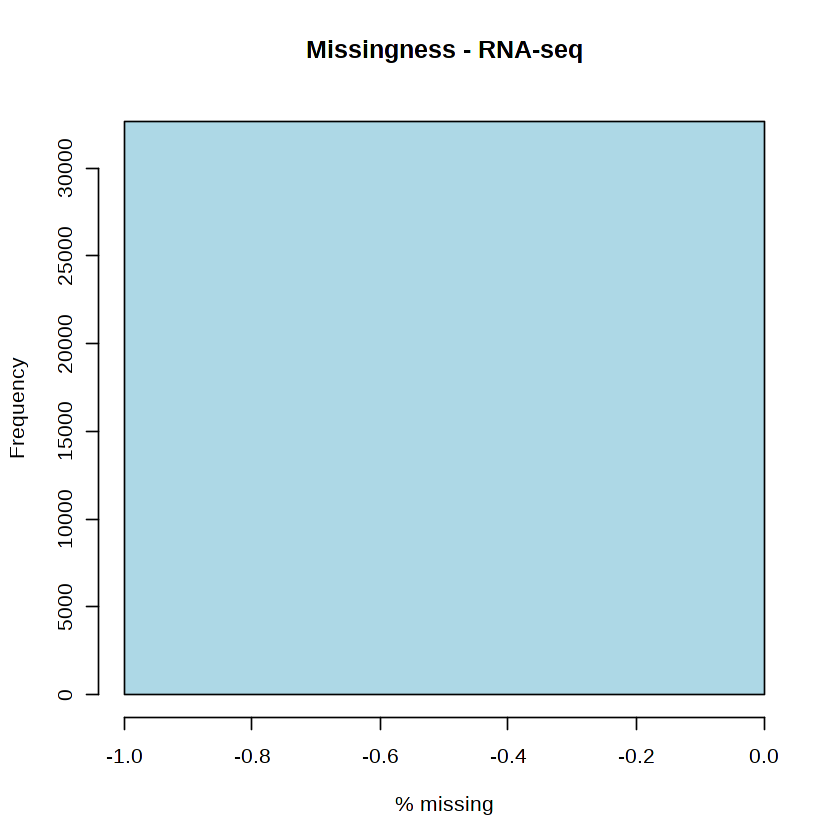

Cluster size 10331 broken into 8547 1784 
Cluster size 8547 broken into 3460 5087 
Cluster size 3460 broken into 2398 1062 
Cluster size 2398 broken into 1289 1109 
Done cluster 1289 
Done cluster 1109 
Done cluster 2398 
Done cluster 1062 
Done cluster 3460 
Cluster size 5087 broken into 2969 2118 
Cluster size 2969 broken into 1366 1603 
Done cluster 1366 
Cluster size 1603 broken into 1601 2 
Cluster size 1601 broken into 763 838 
Done cluster 763 
Done cluster 838 
Done cluster 1601 
Done cluster 2 
Done cluster 1603 
Done cluster 2969 
Cluster size 2118 broken into 2056 62 
Cluster size 2056 broken into 1410 646 
Done cluster 1410 
Done cluster 646 
Done cluster 2056 
Done cluster 62 
Done cluster 2118 
Done cluster 5087 
Done cluster 8547 
Cluster size 1784 broken into 568 1216 
Done cluster 568 
Done cluster 1216 
Done cluster 1784 
Final: 10331 features x 99 samples

==== Methylation ====


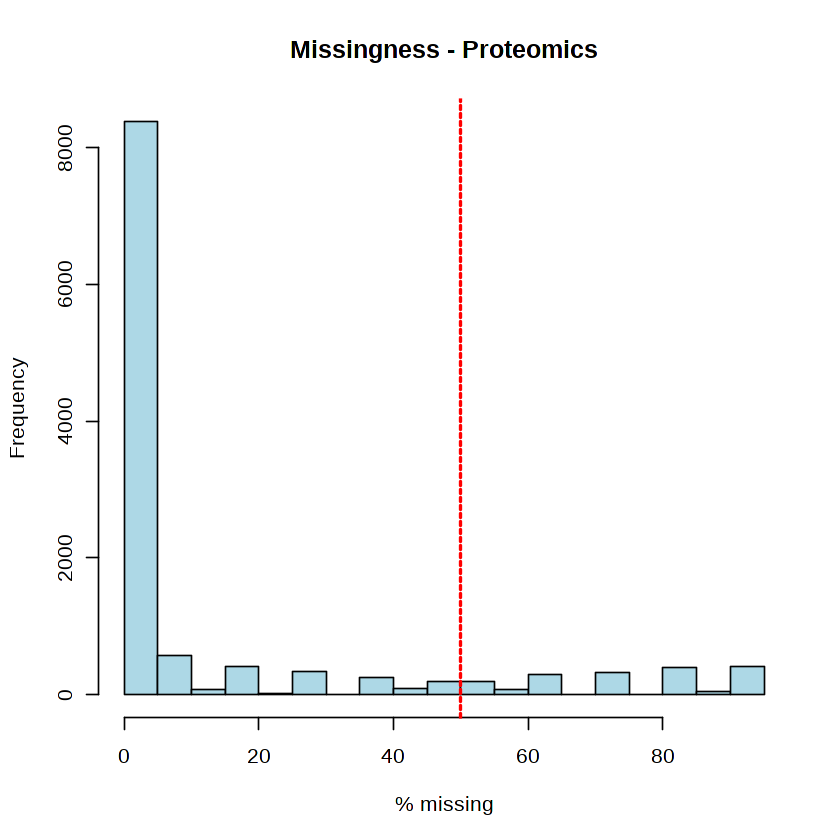

Cluster size 12669 broken into 11910 759 
Cluster size 11910 broken into 8604 3306 
Cluster size 8604 broken into 4600 4004 
Cluster size 4600 broken into 3390 1210 
Cluster size 3390 broken into 1432 1958 
Done cluster 1432 
Cluster size 1958 broken into 982 976 
Done cluster 982 
Done cluster 976 
Done cluster 1958 
Done cluster 3390 
Done cluster 1210 
Done cluster 4600 
Cluster size 4004 broken into 3761 243 
Cluster size 3761 broken into 2931 830 
Cluster size 2931 broken into 888 2043 
Done cluster 888 
Cluster size 2043 broken into 708 1335 
Done cluster 708 
Done cluster 1335 
Done cluster 2043 
Done cluster 2931 
Done cluster 830 
Done cluster 3761 
Done cluster 243 
Done cluster 4004 
Done cluster 8604 
Cluster size 3306 broken into 2974 332 
Cluster size 2974 broken into 2206 768 
Cluster size 2206 broken into 312 1894 
Done cluster 312 
Cluster size 1894 broken into 1176 718 
Done cluster 1176 
Done cluster 718 
Done cluster 1894 
Done cluster 2206 
Done cluster 768 
Done c

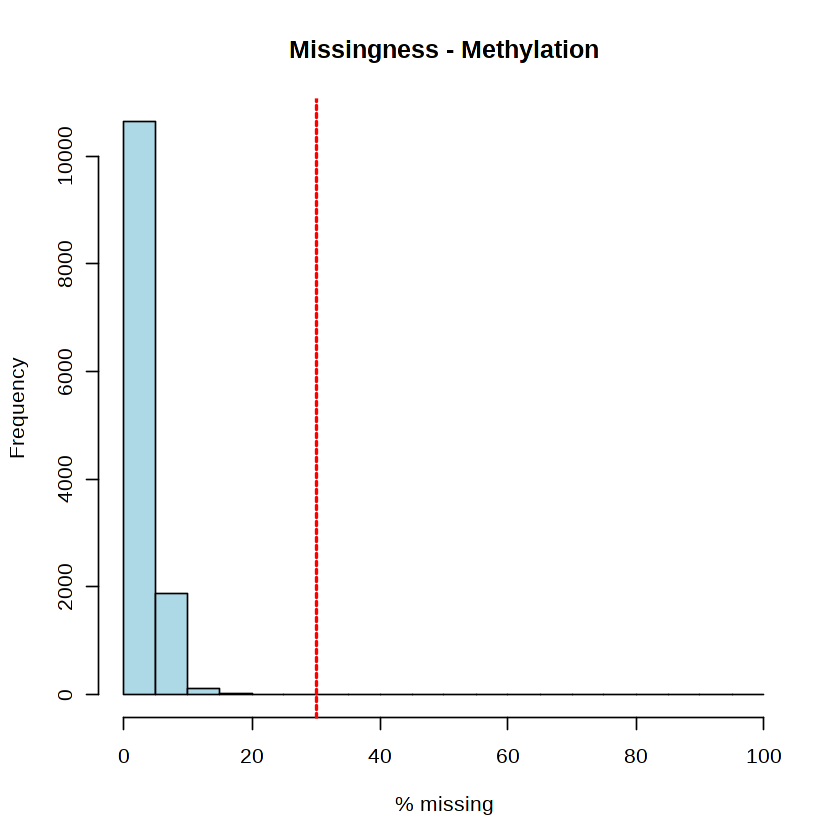

Final: 1983 features x 98 samples


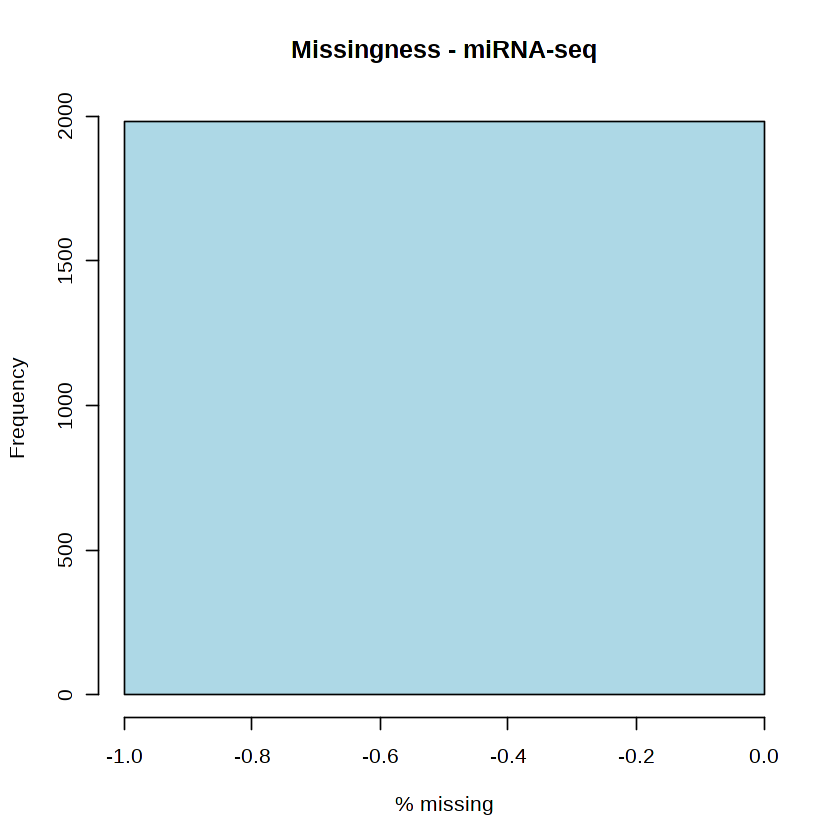

In [ ]:
#QC per layer (missingness + zero-variance filter + KNN impute)
qc_pipeline <- function(mat, name = "layer", missing_thresh = 0.5) {
  cat("\n====", name, "====\n")
  num.mat <- matrix(as.numeric(gsub(",", "", as.matrix(mat))), nrow = nrow(mat), dimnames = dimnames(mat))
  varRow <- apply(num.mat, 1, var, na.rm = TRUE)
  num.mat <- num.mat[!(varRow == 0 | is.na(varRow)), ]
  missRate <- apply(is.na(num.mat), 1, sum) / ncol(num.mat) * 100
  hist(missRate, breaks = 20, main = paste("Missingness -", name), xlab = "% missing", col = "lightblue")
  abline(v = missing_thresh * 100, col = "red", lwd = 2, lty = 2)
  num.mat <- num.mat[missRate < (missing_thresh * 100), ]
  if (sum(is.na(num.mat)) > 0) num.mat <- impute.knn(num.mat, k = 10)$data
  cat("Final:", nrow(num.mat), "features x", ncol(num.mat), "samples\n")
  list(raw = mat, clean = num.mat)
}

par(mfrow = c(1,1))
rna_qc   <- qc_pipeline(rna,  "RNA-seq")
prot_qc  <- qc_pipeline(prot, "Proteomics")
meth_qc  <- qc_pipeline(meth, "Methylation", missing_thresh = 0.3)
mirna_qc <- qc_pipeline(mirna, "miRNA-seq")
mut_clean <- mut[rowSums(mut, na.rm = TRUE) > 0 & rowSums(mut, na.rm = TRUE) < ncol(mut), ]

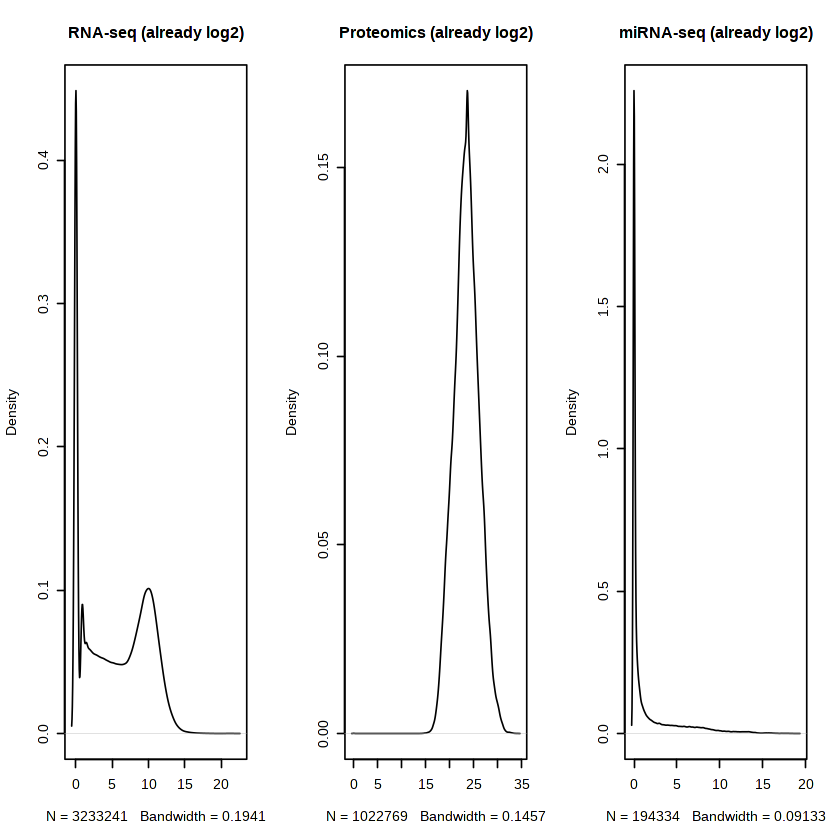

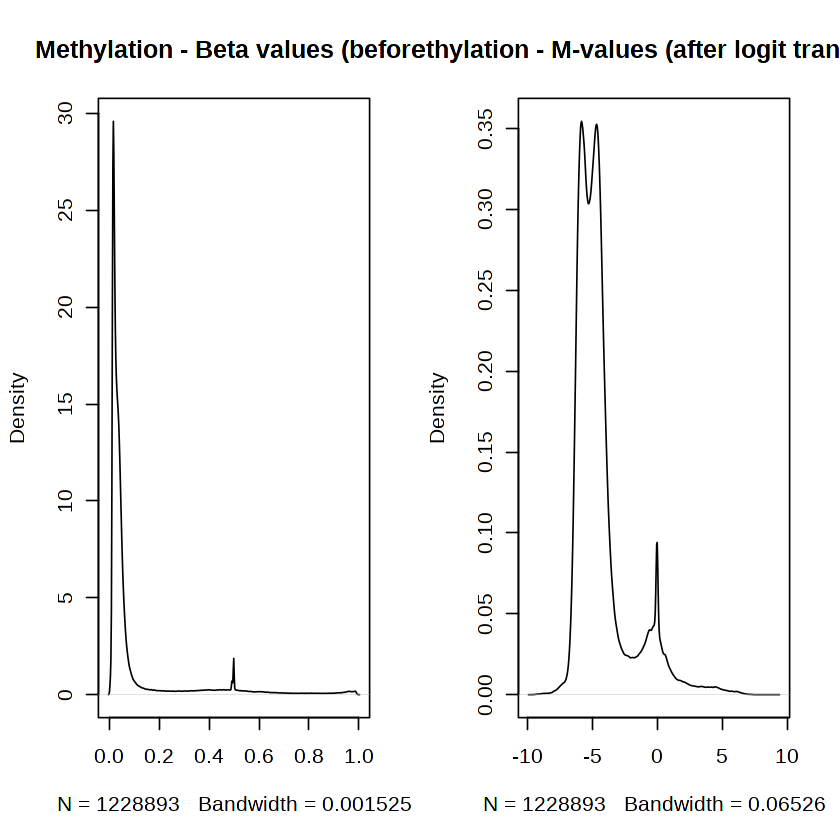

In [ ]:
#Transform: confirm already-log2, apply M-value to methylation
par(mfrow = c(1,3))
plot(density(rna_qc$clean),   main = "RNA-seq (already log2)")
plot(density(prot_qc$clean),  main = "Proteomics (already log2)")
plot(density(mirna_qc$clean), main = "miRNA-seq (already log2)")

beta_to_M <- function(beta, eps = 1e-4) {
  beta <- pmin(pmax(beta, eps), 1 - eps)
  log2(beta / (1 - beta))
}
meth_M <- beta_to_M(meth_qc$clean)

par(mfrow = c(1,2))
plot(density(meth_qc$clean), main = "Methylation - Beta values (before)")
plot(density(meth_M),        main = "Methylation - M-values (after logit transform)")

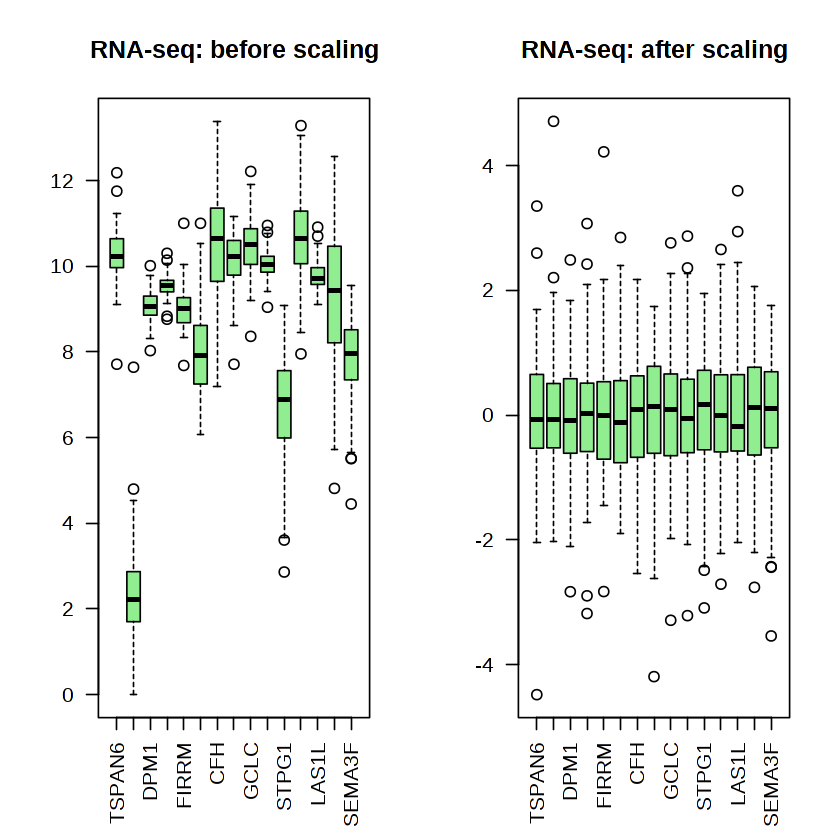

In [ ]:
#Scale (z-score) each layer
scale_features <- function(mat) t(scale(t(mat), center = TRUE, scale = TRUE))

rna_scaled   <- scale_features(rna_qc$clean)
prot_scaled  <- scale_features(prot_qc$clean)
meth_scaled  <- scale_features(meth_M)
mirna_scaled <- scale_features(mirna_qc$clean)

par(mfrow = c(1,2))
boxplot(t(rna_qc$clean)[,1:15], main = "RNA-seq: before scaling", las = 2, col = "lightgreen")
boxplot(t(rna_scaled)[,1:15],   main = "RNA-seq: after scaling",  las = 2, col = "lightgreen")

In [ ]:
#Match samples across ALL layers + attach metadata/survival
common_samples <- Reduce(intersect, list(colnames(rna_scaled), colnames(prot_scaled),
                                          colnames(meth_scaled), colnames(mirna_scaled),
                                          colnames(mut_clean)))
cat("Samples with all layers:", length(common_samples), "\n")

rna_final   <- rna_scaled[,   common_samples]
prot_final  <- prot_scaled[,  common_samples]
meth_final  <- meth_scaled[,  common_samples]
mirna_final <- mirna_scaled[, common_samples]
mut_final   <- mut_clean[,    common_samples]

# Non-scaled versions for DIFFERENTIAL EXPRESSION (limma should see real units,
# not z-scores -- z-scoring collapses the fold-change scale you want to report)
rna_DE   <- rna_qc$clean[,   common_samples]
prot_DE  <- prot_qc$clean[,  common_samples]
meth_DE  <- meth_M[,         common_samples]   # M-values, NOT beta, NOT the z-scored version
mirna_DE <- mirna_qc$clean[, common_samples]

meta_final <- meta[common_samples, , drop = FALSE]
surv_final <- surv[common_samples, , drop = FALSE]

# Verify everything lines up before going further
cat("RNA/metadata overlap:",   length(intersect(colnames(rna_final),  rownames(meta_final))), "\n")
cat("Prot/metadata overlap:",  length(intersect(colnames(prot_final), rownames(meta_final))), "\n")
cat("Meth/metadata overlap:",  length(intersect(colnames(meth_final), rownames(meta_final))), "\n")
cat("miRNA/metadata overlap:", length(intersect(colnames(mirna_final),rownames(meta_final))), "\n")

Samples with all layers: 96 
RNA/metadata overlap: 96 
Prot/metadata overlap: 96 
Meth/metadata overlap: 96 
miRNA/metadata overlap: 96 


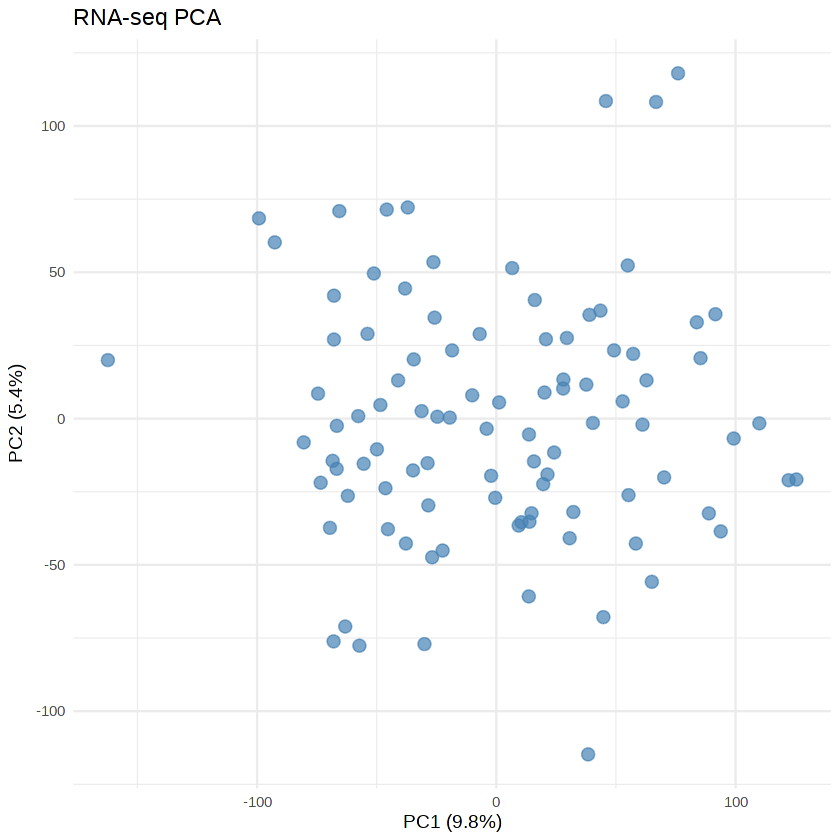

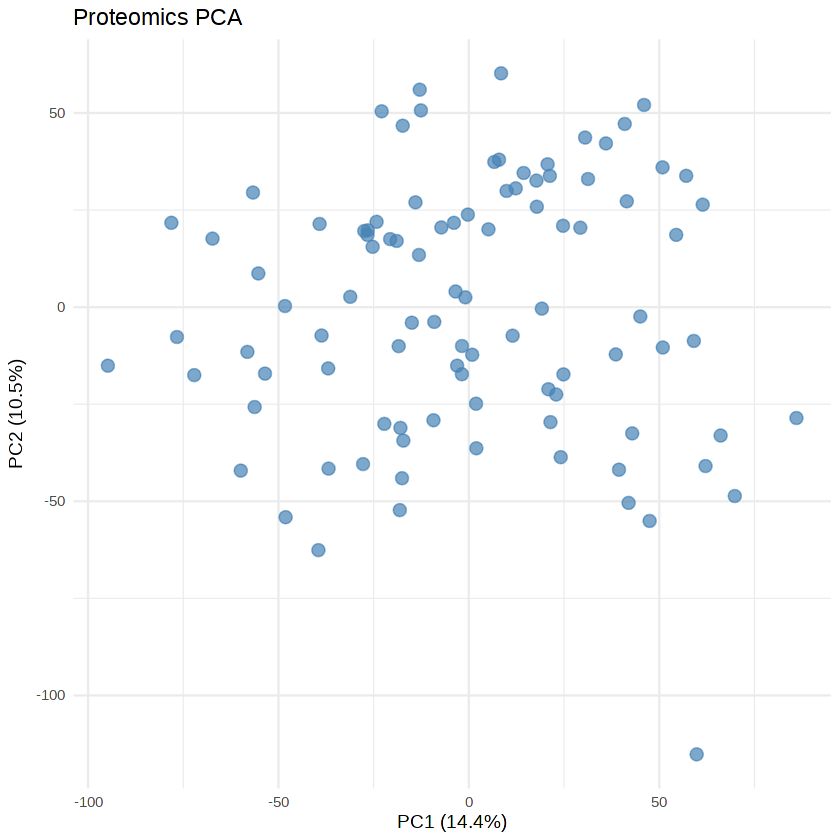

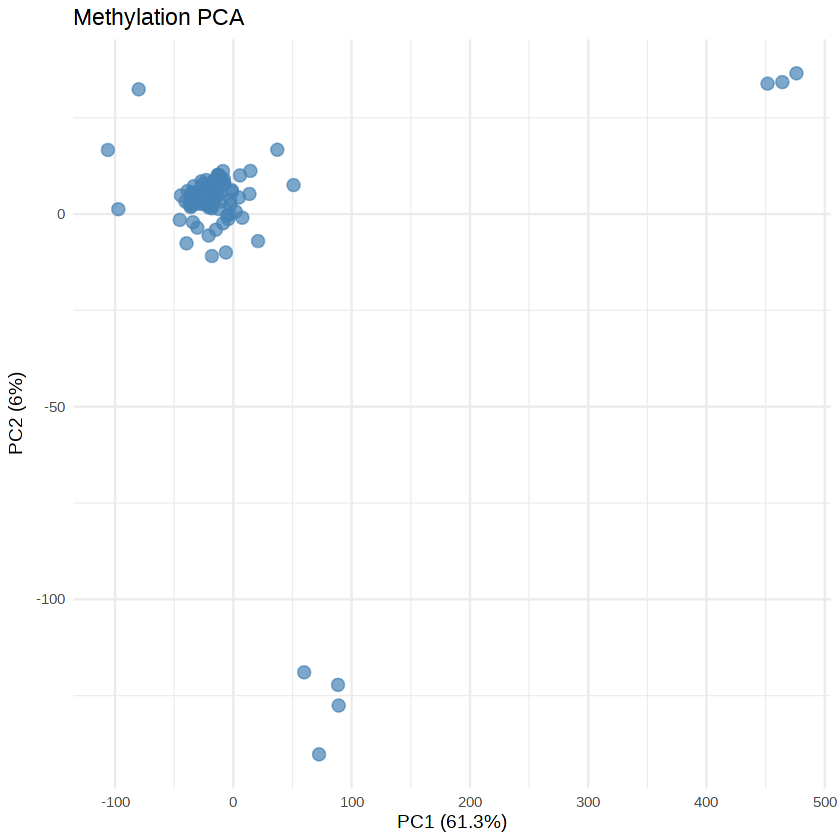

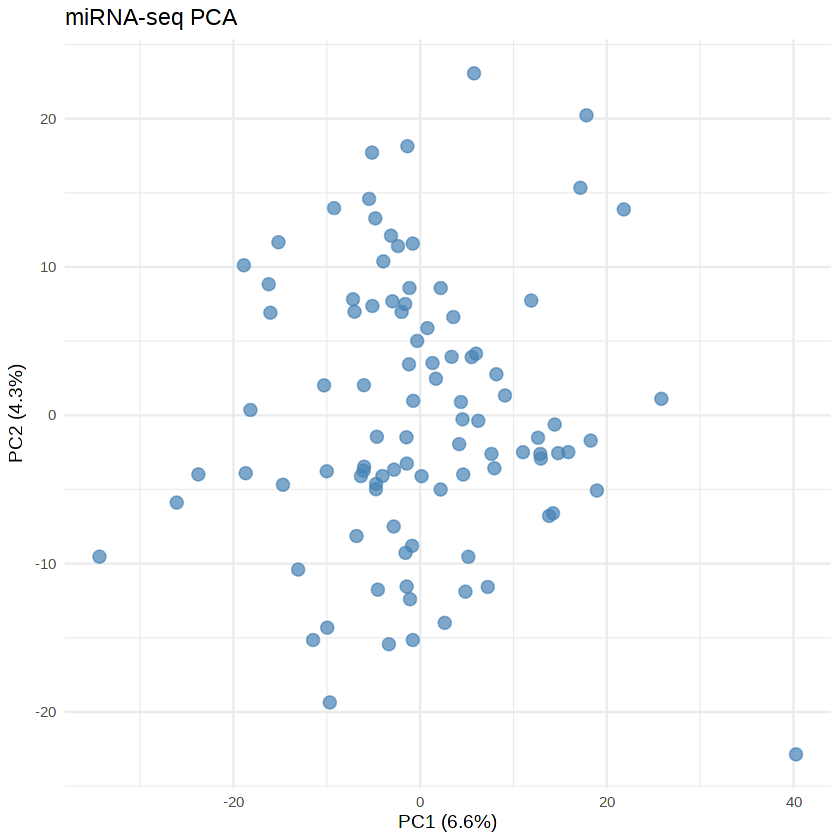

In [ ]:
#Per-layer PCA (outlier / structure check BEFORE integration)
run_pca_plot <- function(mat, title) {
  pca <- prcomp(t(mat), center = TRUE, scale. = FALSE)
  df <- as.data.frame(pca$x)
  ve <- round(100 * summary(pca)$importance[2, 1:2], 1)
  ggplot(df, aes(PC1, PC2)) + geom_point(size = 3, alpha = 0.7, color = "steelblue") +
    labs(title = title, x = paste0("PC1 (", ve[1], "%)"), y = paste0("PC2 (", ve[2], "%)")) + theme_minimal()
}
print(run_pca_plot(rna_final,  "RNA-seq PCA"))
print(run_pca_plot(prot_final, "Proteomics PCA"))
print(run_pca_plot(meth_final, "Methylation PCA"))
print(run_pca_plot(mirna_final,"miRNA-seq PCA"))

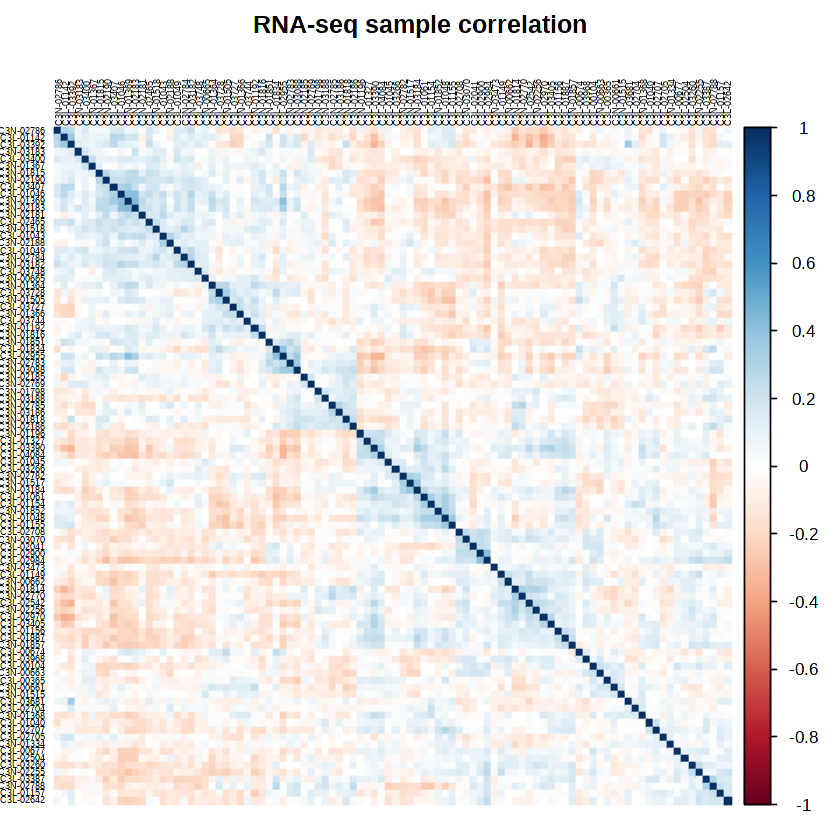

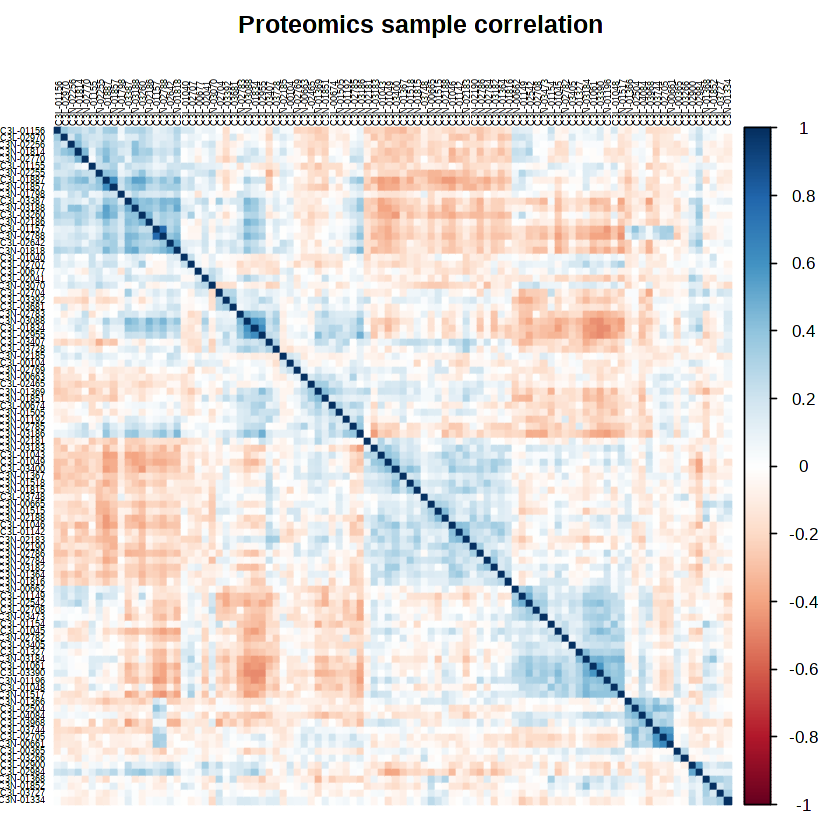

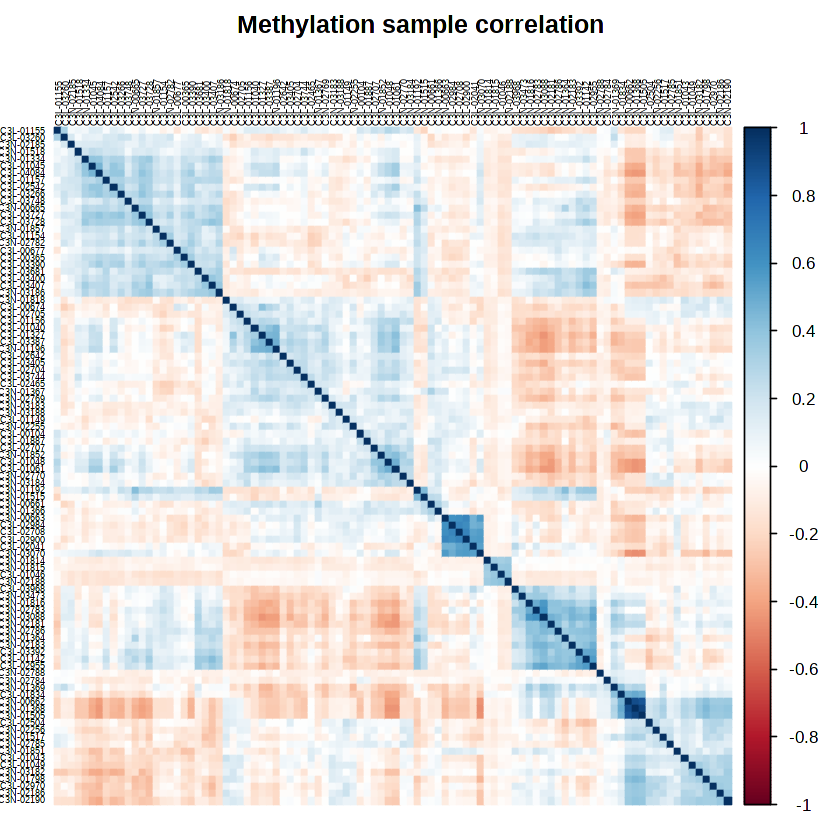

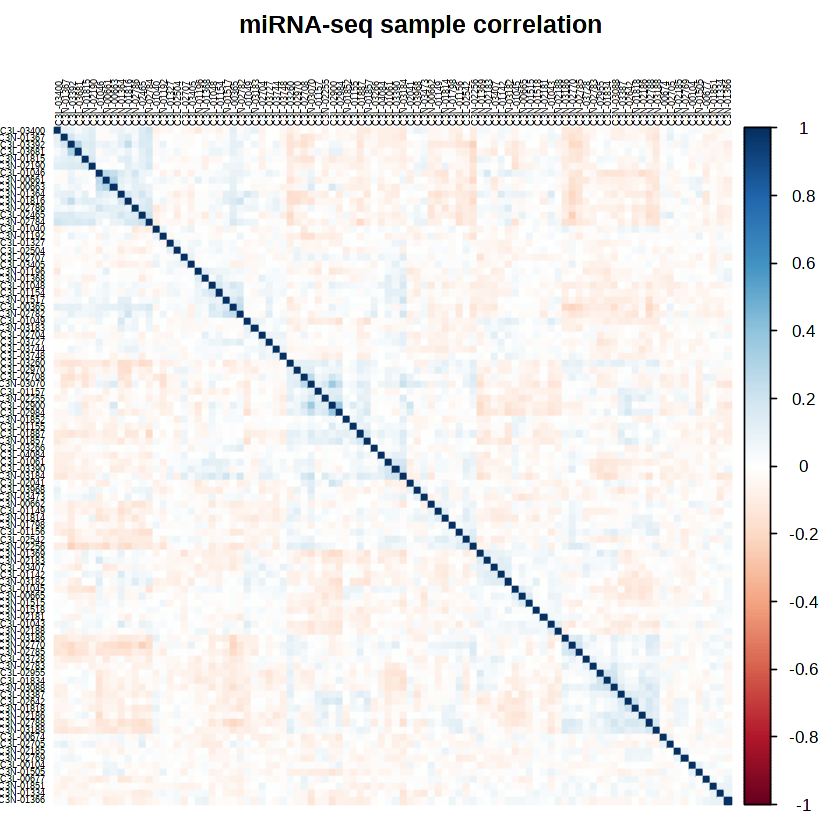

In [ ]:
#Sample-sample correlation heatmaps
plot_sample_correlation <- function(mat, title) {
  cor_mat <- cor(mat, use = "pairwise.complete.obs")
  corrplot::corrplot(cor_mat, method = "color", order = "hclust",
                      tl.cex = 0.4, tl.col = "black", title = title, mar = c(0,0,2,0))
  invisible(cor_mat)
}
rna_cor   <- plot_sample_correlation(rna_final,   "RNA-seq sample correlation")
prot_cor  <- plot_sample_correlation(prot_final,  "Proteomics sample correlation")
meth_cor  <- plot_sample_correlation(meth_final,  "Methylation sample correlation")
mirna_cor <- plot_sample_correlation(mirna_final, "miRNA-seq sample correlation")

In [ ]:
#Flag potential outlier samples
mean_sample_cor <- function(cor_mat) {
  m <- cor_mat; diag(m) <- NA
  rowMeans(m, na.rm = TRUE)
}
sample_qc <- data.frame(
  sample = common_samples,
  RNA_mean_cor   = mean_sample_cor(rna_cor)[common_samples],
  Prot_mean_cor  = mean_sample_cor(prot_cor)[common_samples],
  Meth_mean_cor  = mean_sample_cor(meth_cor)[common_samples],
  miRNA_mean_cor = mean_sample_cor(mirna_cor)[common_samples]
)
# Samples with a LOW mean correlation to everyone else are the ones to look at closely --
# especially for Methylation, given what we saw in the PCA (PC1 = 61.3%, driven by a
# small number of extreme points). Sort and inspect the bottom of this list:
sample_qc %>% arrange(Meth_mean_cor) %>% head(10)

,sample,RNA_mean_cor,Prot_mean_cor,Meth_mean_cor,miRNA_mean_cor
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
C3N-00662,C3N-00662,-0.0104683699,-0.0089070283,-0.06081822,-0.016902636
C3N-01505,C3N-01505,-0.0092400895,-0.0103829300,-0.06074188,-0.017699793
C3N-01368,C3N-01368,-0.0007449521,-0.0003150593,-0.06038402,-0.005455712
C3L-01046,C3L-01046,-0.0169122663,-0.0160830072,-0.05776893,-0.006059580
C3N-02188,C3N-02188,-0.0024918067,-0.0040702020,-0.05556642,-0.008573615
C3N-01814,C3N-01814,-0.0077591465,-0.0049643817,-0.05243659,-0.010934667
C3N-01815,C3N-01815,-0.0101137859,-0.0107372997,-0.05198711,-0.012284354
C3N-02788,C3N-02788,-0.0084609799,-0.0117088162,-0.04343142,-0.013770342
C3L-01834,C3L-01834,-0.0112215241,-0.0064347178,-0.04304844,-0.016697521


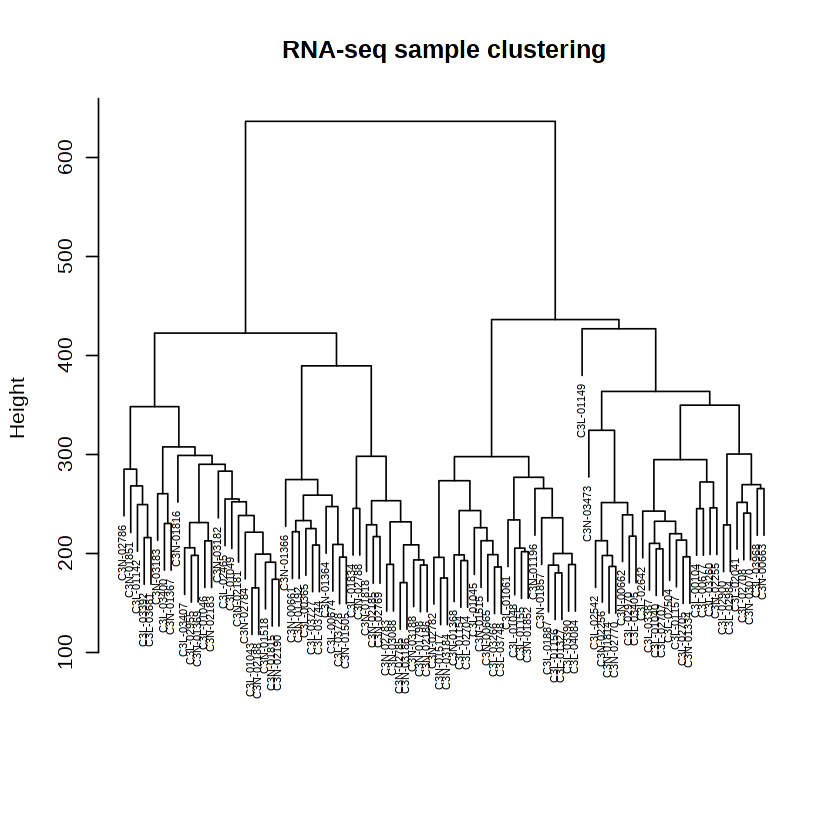

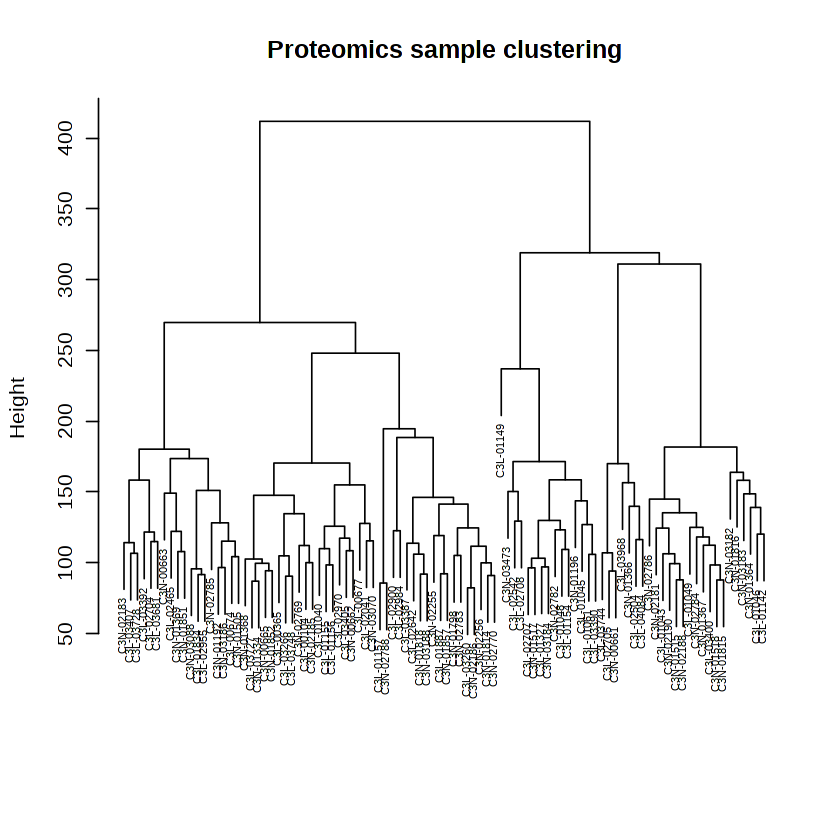

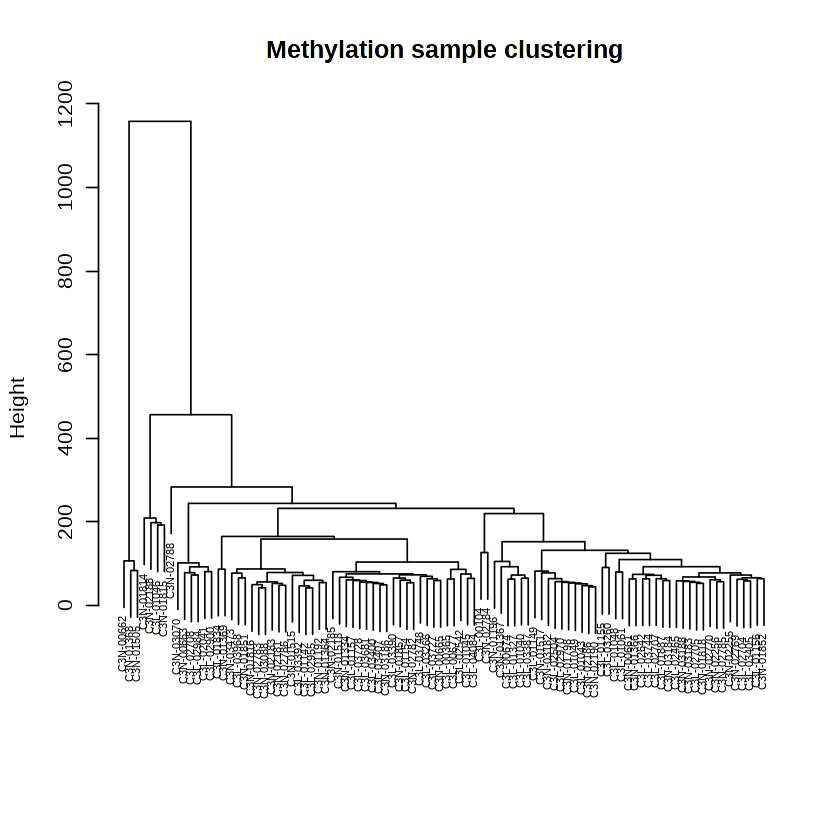

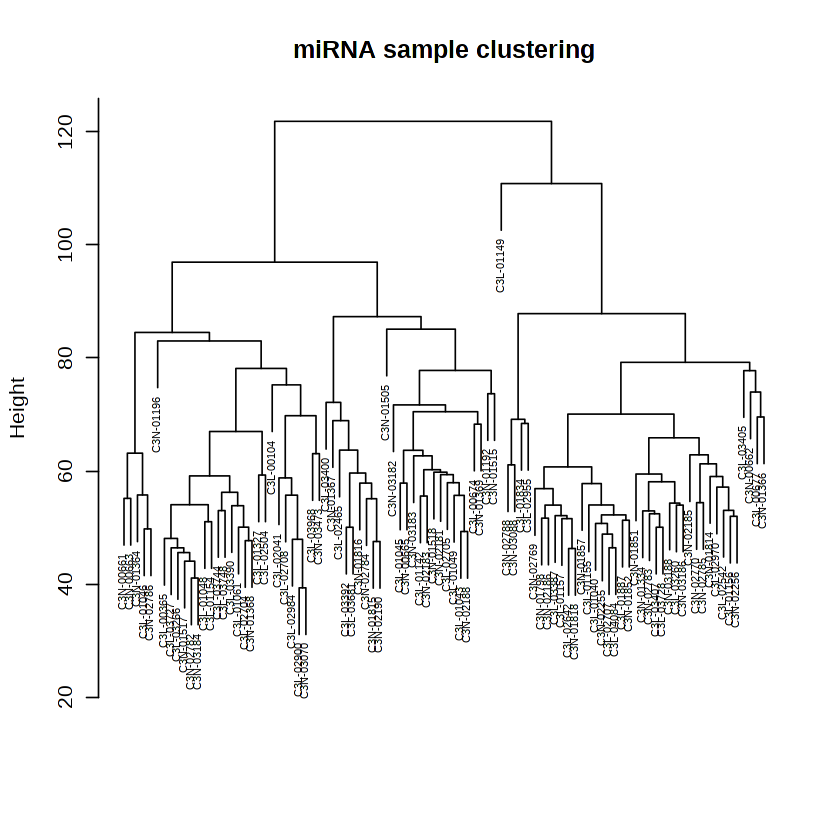

In [ ]:
#Hierarchical clustering per layer (complements the correlation heatmap)
plot_sample_clustering <- function(mat, title) {
  hc <- hclust(dist(t(mat)), method = "ward.D2")
  plot(hc, main = title, xlab = "", sub = "", cex = 0.5)
  invisible(hc)
}
plot_sample_clustering(rna_final,   "RNA-seq sample clustering")
plot_sample_clustering(prot_final,  "Proteomics sample clustering")
plot_sample_clustering(meth_final,  "Methylation sample clustering")
plot_sample_clustering(mirna_final, "miRNA sample clustering")

In [ ]:
#EGFR grouping variable (used by all 4 DE analyses below)
group_all <- factor(meta_final$EGFR_mutation, levels = c(0, 1), labels = c("EGFR_WT", "EGFR_mutant"))
table(group_all)

run_limma_DE <- function(mat_DE, group, label) {
  keep <- apply(mat_DE, 1, var, na.rm = TRUE) > 0
  mat_DE <- mat_DE[keep, , drop = FALSE]
  design <- model.matrix(~0 + group); colnames(design) <- levels(group)
  contrast <- makeContrasts(EGFR_mutant - EGFR_WT, levels = design)
  fit  <- lmFit(mat_DE, design)
  fit2 <- eBayes(contrasts.fit(fit, contrast))
  res <- topTable(fit2, number = Inf, adjust.method = "BH")
  res$Gene <- rownames(res)
  res$Regulation <- with(res, ifelse(adj.P.Val < 0.05 & logFC >  1, "Up",
                               ifelse(adj.P.Val < 0.05 & logFC < -1, "Down", "NS")))
  cat(label, "-- features tested:", nrow(mat_DE), "\n")
  print(table(res$Regulation))
  res
}

volcano_plot <- function(res, title) {
  ggplot(res, aes(logFC, -log10(adj.P.Val), color = Regulation)) +
    geom_point(alpha = 0.6) +
    scale_color_manual(values = c(Up = "firebrick", Down = "steelblue", NS = "grey70")) +
    geom_vline(xintercept = c(-1, 1), linetype = "dashed") +
    geom_hline(yintercept = -log10(0.05), linetype = "dashed") +
    labs(title = title, x = "log2FC", y = "-log10(adj. p-value)") + theme_minimal()
}

group_all
    EGFR_WT EGFR_mutant 
         73          23 

RNA-seq -- features tested: 32635 

   NS    Up 
32634     1 


,logFC,AveExpr,t,P.Value,adj.P.Val,B,Gene,Regulation
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
RPL7P4,-0.8309974,1.722252,-5.689265,1.384385e-07,0.004517939,5.872065,RPL7P4,NS
EGFR,2.9938070,14.304011,5.221453,1.030411e-06,0.016813734,4.327388,EGFR,Up


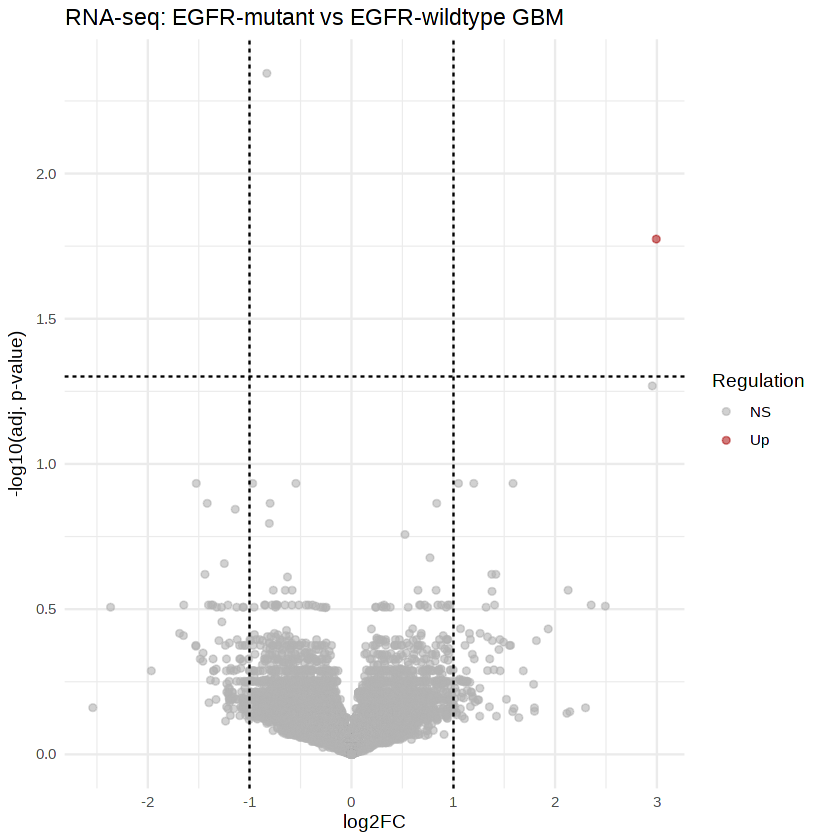

In [ ]:
#RNA-seq DE (EGFR-mutant vs WT)
DEGs <- run_limma_DE(rna_DE, group_all, "RNA-seq")
print(volcano_plot(DEGs, "RNA-seq: EGFR-mutant vs EGFR-wildtype GBM"))
top_DEGs <- DEGs %>% filter(adj.P.Val < 0.05) %>% arrange(adj.P.Val)
head(top_DEGs, 20)

Proteomics -- features tested: 10331 

   NS 
10331 


logFC,AveExpr,t,P.Value,adj.P.Val,B,Gene,Regulation
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>


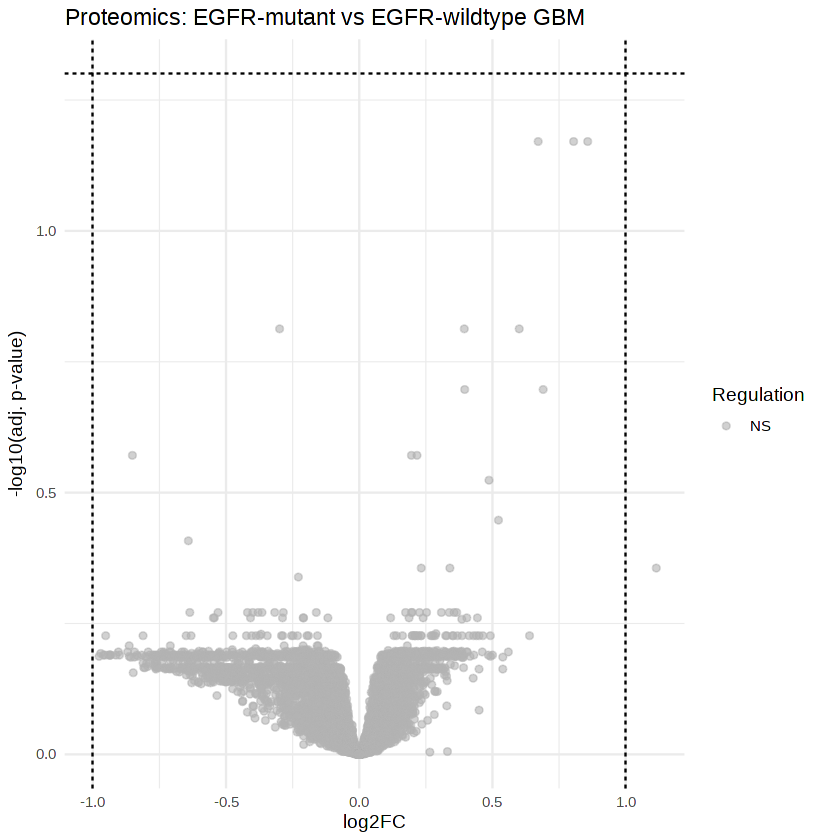

In [ ]:
#Proteomics DE
DE_proteins <- run_limma_DE(prot_DE, group_all, "Proteomics")
print(volcano_plot(DE_proteins, "Proteomics: EGFR-mutant vs EGFR-wildtype GBM"))
top_DE_proteins <- DE_proteins %>% filter(adj.P.Val < 0.05) %>% arrange(adj.P.Val)
head(top_DE_proteins, 20)

Methylation (M-values) -- features tested: 12669 

   NS 
12669 


logFC,AveExpr,t,P.Value,adj.P.Val,B,Gene,Regulation
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>


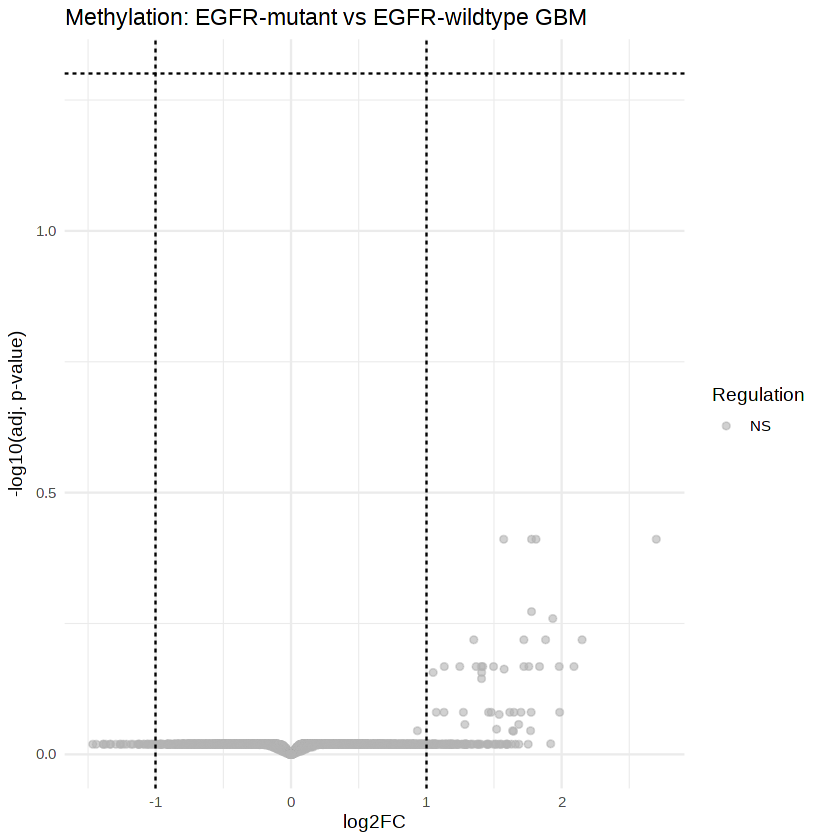

In [ ]:
#Methylation DE
DMGs <- run_limma_DE(meth_DE, group_all, "Methylation (M-values)")
print(volcano_plot(DMGs, "Methylation: EGFR-mutant vs EGFR-wildtype GBM"))
top_DMGs <- DMGs %>% filter(adj.P.Val < 0.05) %>% arrange(adj.P.Val)
head(top_DMGs, 20)

miRNA-seq -- features tested: 1983 

  NS 
1983 


logFC,AveExpr,t,P.Value,adj.P.Val,B,Gene,Regulation
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>


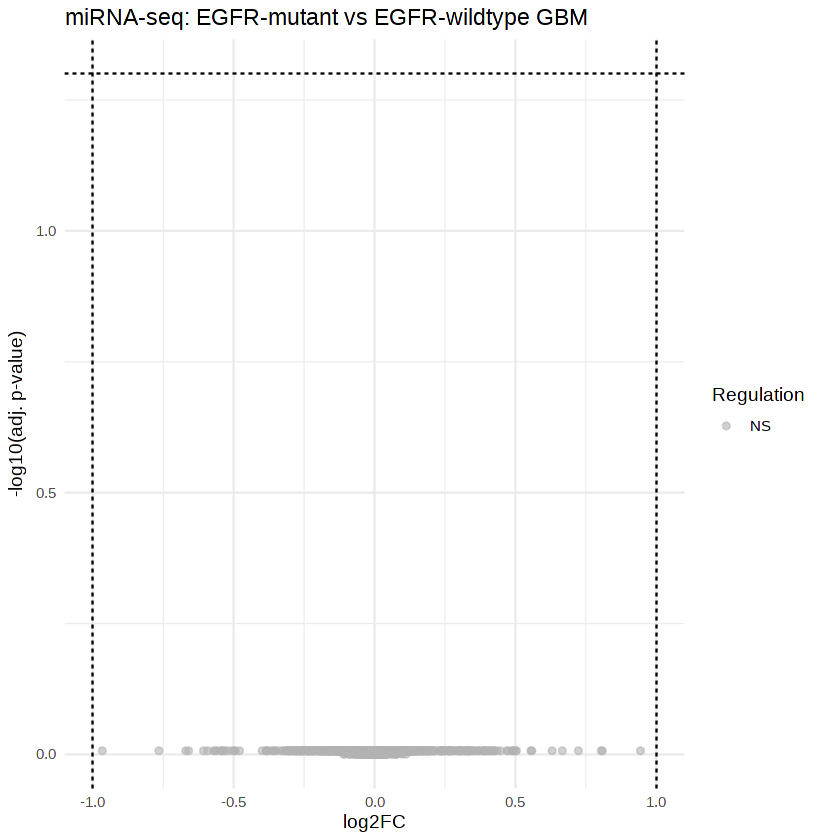

In [ ]:
#miRNA DE
DE_miRNAs <- run_limma_DE(mirna_DE, group_all, "miRNA-seq")
print(volcano_plot(DE_miRNAs, "miRNA-seq: EGFR-mutant vs EGFR-wildtype GBM"))
top_DE_miRNAs <- DE_miRNAs %>% filter(adj.P.Val < 0.05) %>% arrange(adj.P.Val)
head(top_DE_miRNAs, 20)

In [ ]:
#DE summary across all 4 layers (now this will actually work)
cat("RNA-seq:\n");     print(table(DEGs$Regulation))
cat("Proteomics:\n");  print(table(DE_proteins$Regulation))
cat("Methylation:\n"); print(table(DMGs$Regulation))
cat("miRNA:\n");       print(table(DE_miRNAs$Regulation))

RNA-seq:

   NS    Up 
32634     1 
Proteomics:

   NS 
10331 
Methylation:

   NS 
12669 
miRNA:

  NS 
1983 


mRNA,Proteomics,Methylation,miRNA,Mutations
5000,5000,5000,1983,4614
96,96,96,96,96


Creating MOFA object from a list of matrices (features as rows, sample as columns)...


Warning message in .rename_duplicated_features(object):
“There are duplicated features names across different views. We will add the suffix *_view* only for those features 
            Example: if you have both TP53 in mRNA and mutation data it will be renamed to TP53_mRNA, TP53_mutation”


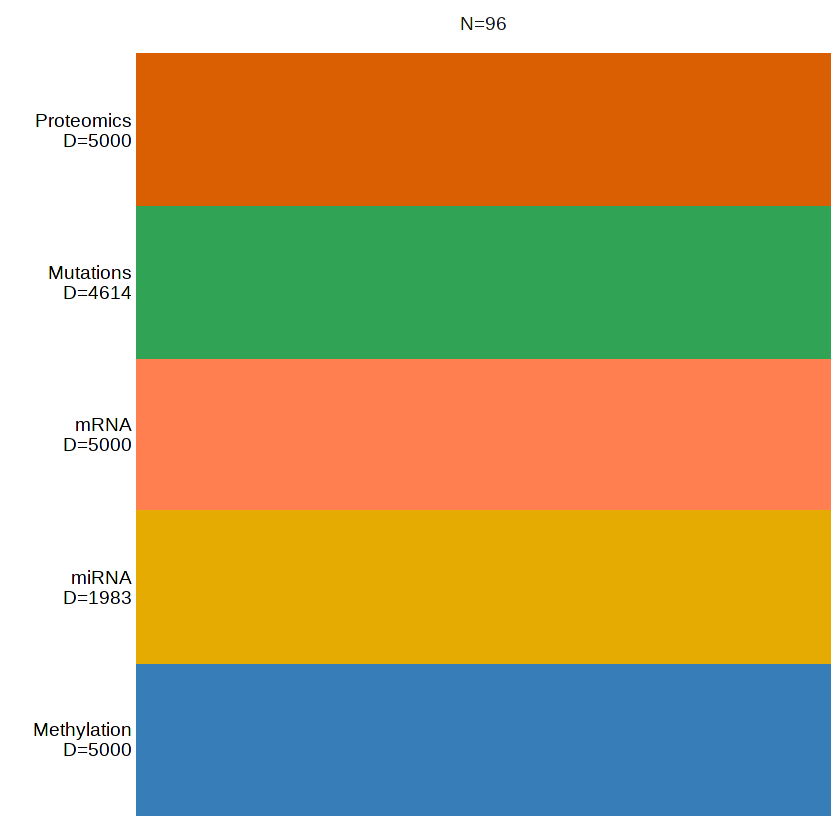

In [ ]:
#Top-variable feature selection + build MOFA object
select_top_variable <- function(mat, n = 5000) {
  v <- apply(mat, 1, var, na.rm = TRUE)
  mat[order(v, decreasing = TRUE)[1:min(n, nrow(mat))], , drop = FALSE]
}
rna_mofa   <- select_top_variable(rna_final,  n = 5000)
prot_mofa  <- select_top_variable(prot_final, n = 5000)
meth_mofa  <- select_top_variable(meth_final, n = 5000)
mirna_mofa <- mirna_final   # already has only ~2,000 features -- no need to subset further
mut_mofa   <- mut_final     # binary -- never variance-select the same way as continuous data

omics_list <- list(mRNA = as.matrix(rna_mofa), Proteomics = as.matrix(prot_mofa),
                    Methylation = as.matrix(meth_mofa), miRNA = as.matrix(mirna_mofa),
                    Mutations = as.matrix(mut_mofa))
stopifnot(all(sapply(omics_list, function(x) identical(colnames(x), common_samples))))
sapply(omics_list, dim)

MOFAobject <- create_mofa(omics_list)
plot_data_overview(MOFAobject)

In [ ]:
#Model + training options, train
model_opts <- get_default_model_options(MOFAobject)
model_opts$num_factors <- 10
model_opts$likelihoods["Mutations"] <- "bernoulli"
model_opts$likelihoods

train_opts <- get_default_training_options(MOFAobject)
train_opts$convergence_mode <- "fast"

MOFAobject <- prepare_mofa(MOFAobject, model_options = model_opts, training_options = train_opts)
MOFAobject <- run_mofa(MOFAobject, outfile = "GBM_MOFA_model.hdf5", use_basilisk = FALSE)
saveRDS(MOFAobject, "GBM_MOFA_model.rds")

mRNA  Proteomics Methylation       miRNA   Mutations 
 "gaussian"  "gaussian"  "gaussian"  "gaussian" "bernoulli"

Checking data options...

No data options specified, using default...

Checking training options...

Checking model options...


Connecting to the mofapy2 python package using reticulate (use_basilisk = FALSE)... 
    Please make sure to manually specify the right python binary when loading R with reticulate::use_python(..., force=TRUE) or the right conda environment with reticulate::use_condaenv(..., force=TRUE)
    If you prefer to let us automatically install a conda environment with 'mofapy2' installed using the 'basilisk' package, please use the argument 'use_basilisk = TRUE'


Warning message in run_mofa(MOFAobject, outfile = "GBM_MOFA_model.hdf5", use_basilisk = FALSE):
“The latest mofapy2 version is 0.7.3, you are using 0.7.4. Please upgrade with 'pip install mofapy2'”
Warning message in .quality_control(object, verbose = verbose):
“Factor(s) 1 are strongly correlated with the average expression of features for at least one of your omics. Such factors appear when there are diff

In [ ]:
#Attach metadata + survival to the trained model
colnames(meta_final)[colnames(meta_final) == "case_id"] <- "sample"   # avoids the rename() namespace collision
colnames(surv_final)[colnames(surv_final) == "case_id"] <- "sample"
meta_mofa <- meta_final %>% left_join(surv_final, by = "sample")
samples_metadata(MOFAobject) <- meta_mofa
head(meta_mofa)

,sample,Age,Sex,Tumor_Size_cm,Histologic_Grade,Tumor_necrosis,Path_Stage_pT,Path_Stage_pN,Stage,BMI,⋯,ATRX_mutation,PIK3CA_mutation,RB1_mutation,TP53_mutation,EGFR_mutation,PTEN_mutation,OS_days,OS_event,PFS_days,PFS_event
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>
1,C3L-00104,58,Male,1,NA,NA,NA,NA,NA,32.54,⋯,0,0,1,1,0,1,129,1,101,1
2,C3L-00365,59,Female,1.2,NA,NA,NA,NA,NA,20.61,⋯,0,0,1,1,1,0,322,1,280,0
3,C3L-00674,45,Male,4.9,NA,NA,NA,NA,NA,27.44,⋯,0,0,0,0,1,1,478,1,194,1
4,C3L-00677,69,Female,4.5,NA,NA,NA,NA,NA,19.32,⋯,1,0,1,1,0,1,155,1,155,0
5,C3L-01040,77,Male,5,NA,NA,NA,NA,NA,24.22,⋯,0,0,0,0,0,0,608,0,559,1
6,C3L-01043,59,Male,5,NA,NA,NA,NA,NA,24.22,⋯,0,0,0,0,0,1,79,1,NA,0


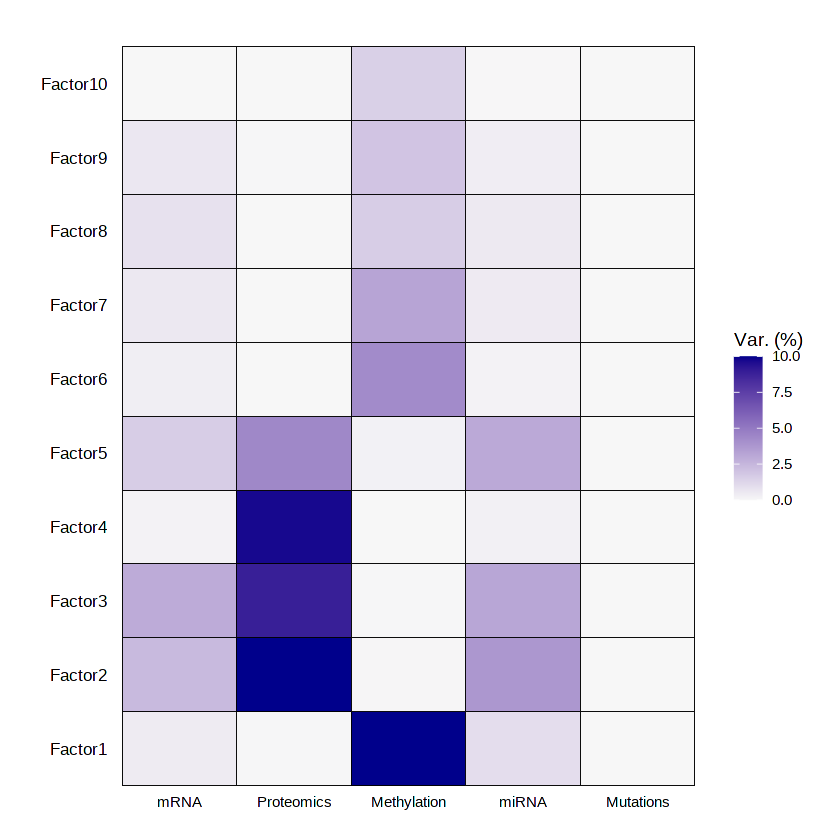

[[1]]

[[2]]


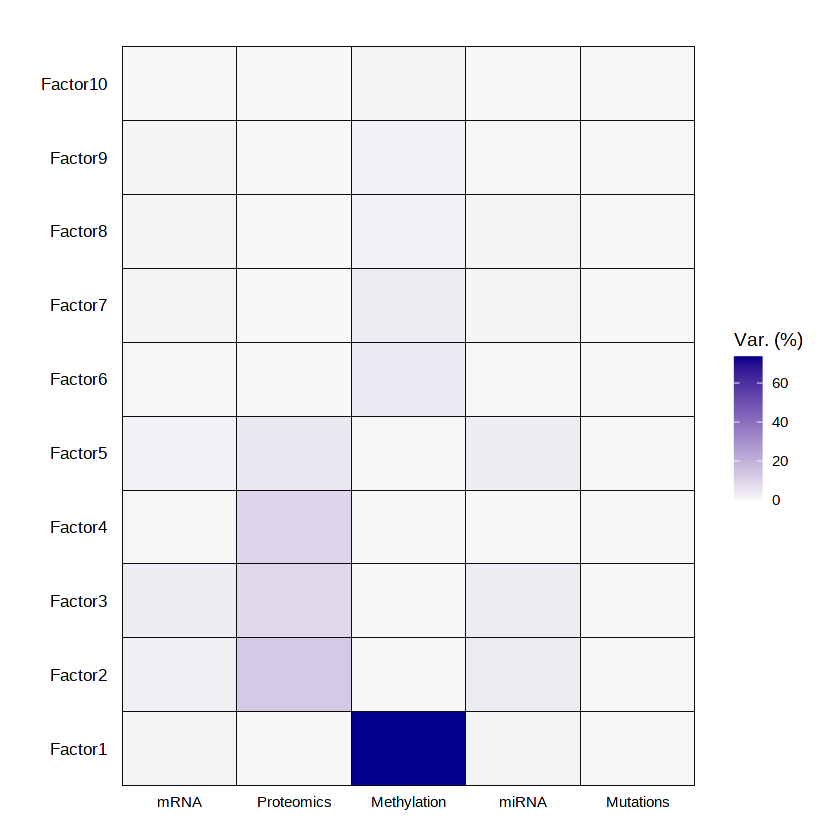

group,view,value
<fct>,<fct>,<dbl>
group1,mRNA,9.82089043
group1,Proteomics,35.86519957
group1,Methylation,86.15243435
group1,miRNA,12.63291240
group1,Mutations,0.07101297


group,view,factor,value
<chr>,<fct>,<fct>,<dbl>
group1,mRNA,Factor1,0.451642275
group1,mRNA,Factor2,2.385425568
group1,mRNA,Factor3,2.952152491
group1,mRNA,Factor4,0.198692083
group1,mRNA,Factor5,1.629990339
group1,mRNA,Factor6,0.361353159
group1,mRNA,Factor7,0.563031435
group1,mRNA,Factor8,0.836116076
group1,mRNA,Factor9,0.594502687


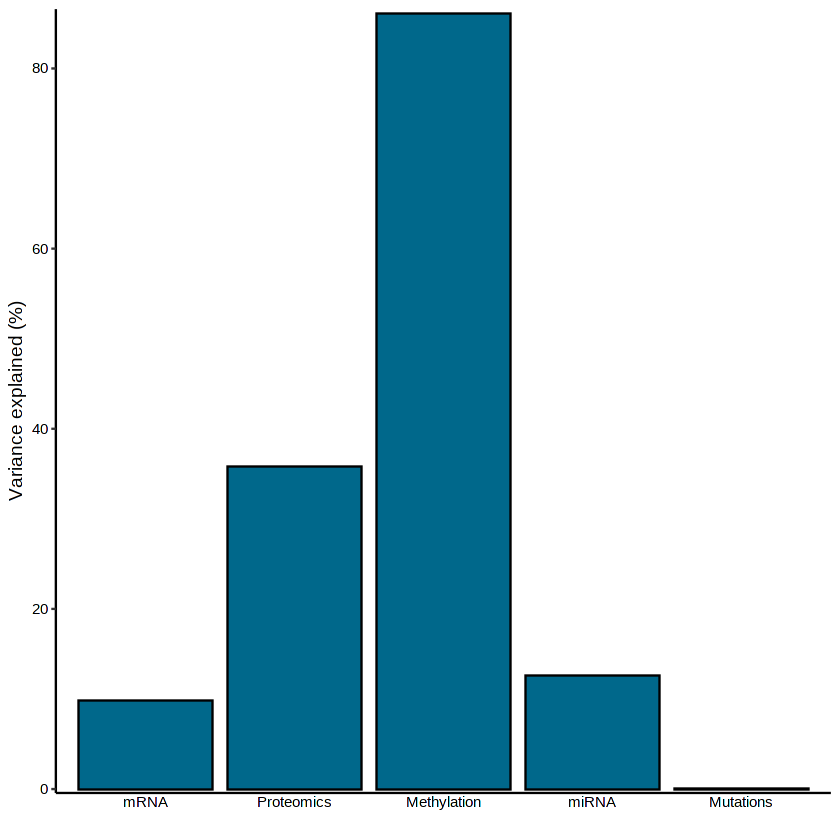

In [ ]:
#Variance decomposition (THE key output)
plot_variance_explained(MOFAobject, max_r2 = 10)
plot_variance_explained(MOFAobject, plot_total = TRUE)

r2 <- get_variance_explained(MOFAobject, as.data.frame = TRUE)
r2$r2_total
r2$r2_per_factor

Warning message in correlate_factors_with_covariates(MOFAobject, covariates = c("Age", :
“There are non-numeric values in the covariates data.frame, converting to numeric...”


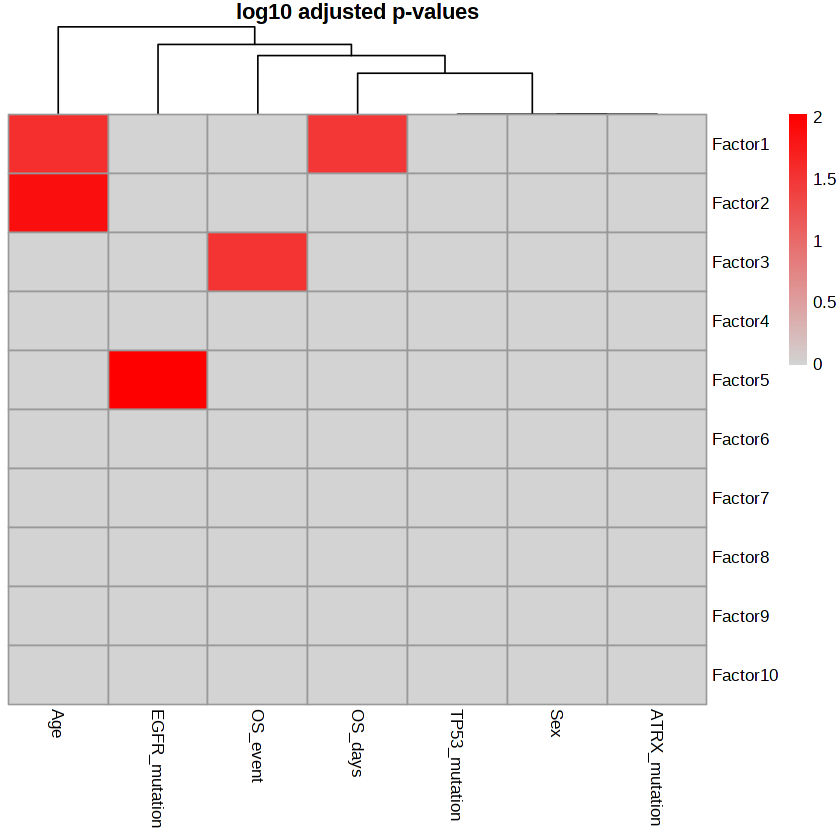

In [ ]:
#Correlate factors with clinical covariates
correlate_factors_with_covariates(MOFAobject,
  covariates = c("Age","Sex","OS_days","OS_event","EGFR_mutation","ATRX_mutation","TP53_mutation"),
  plot = "log_pval")

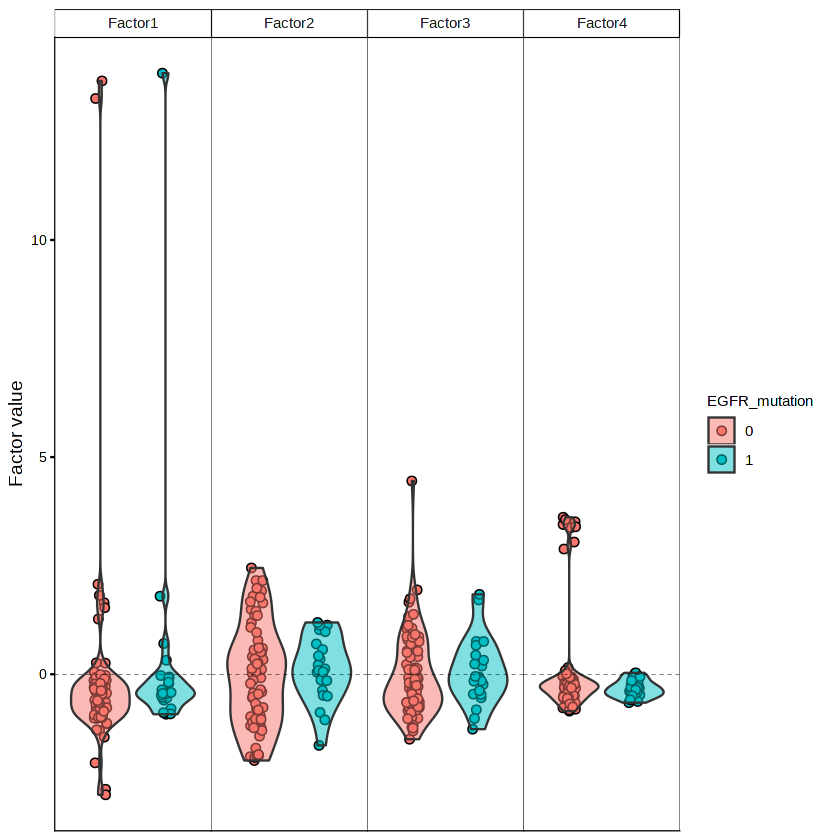

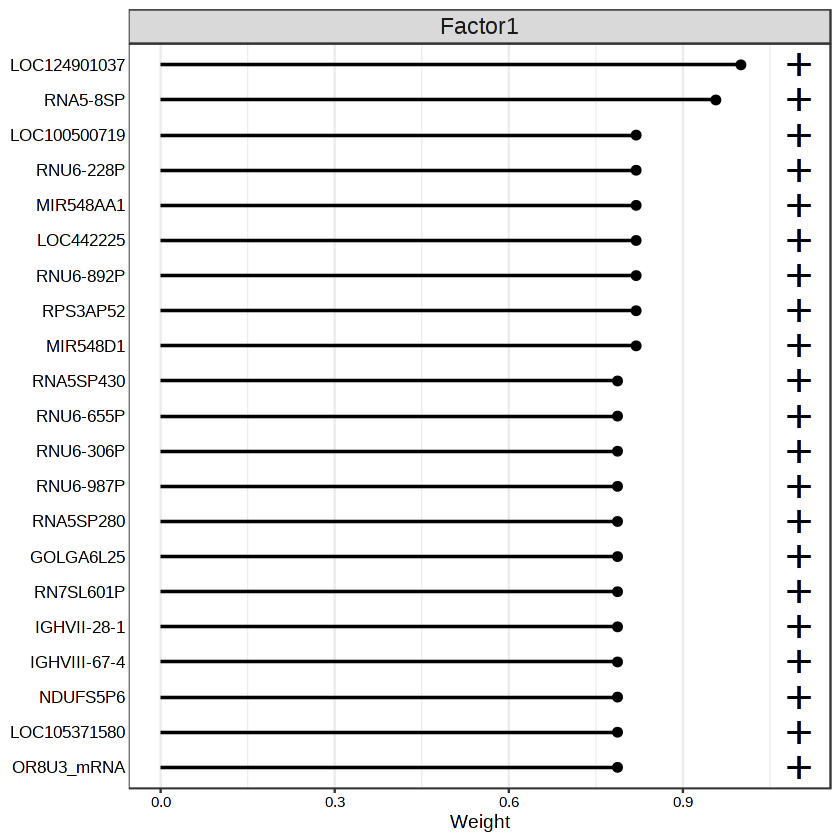

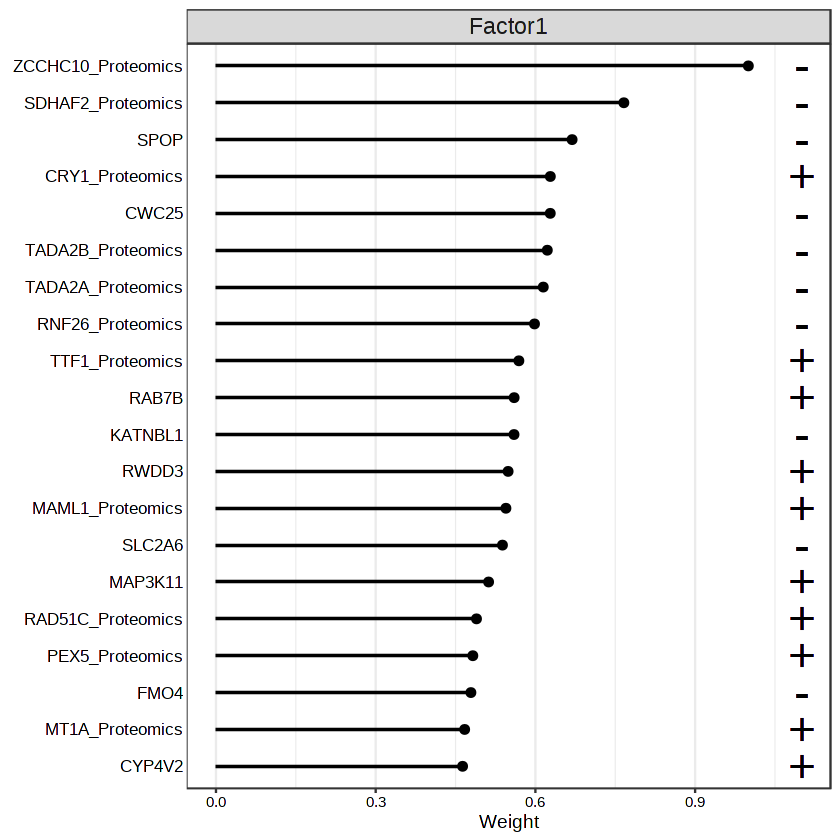

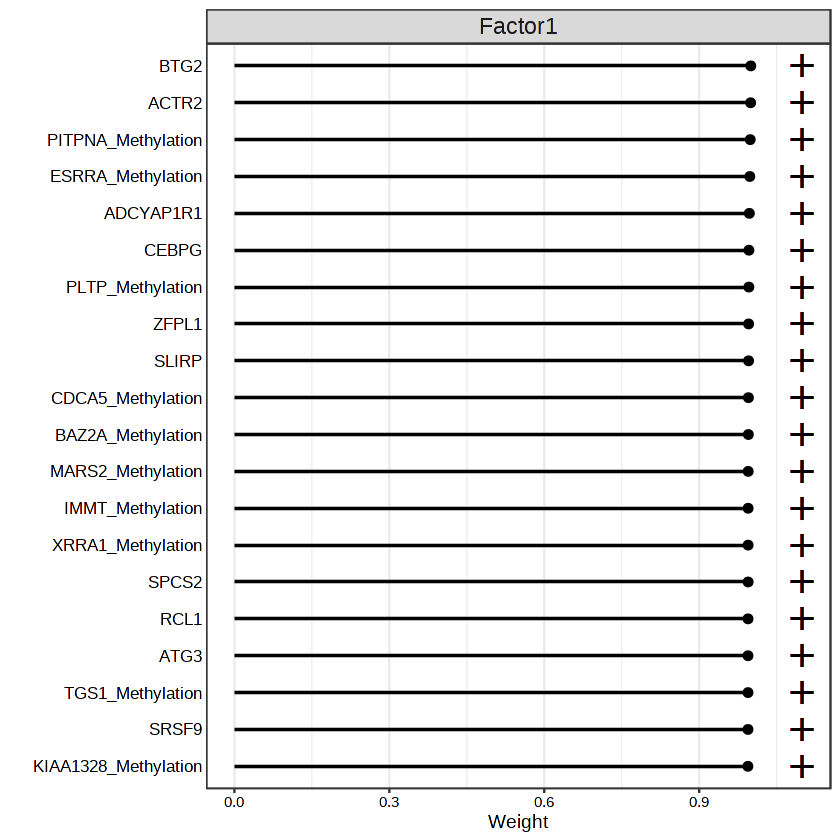

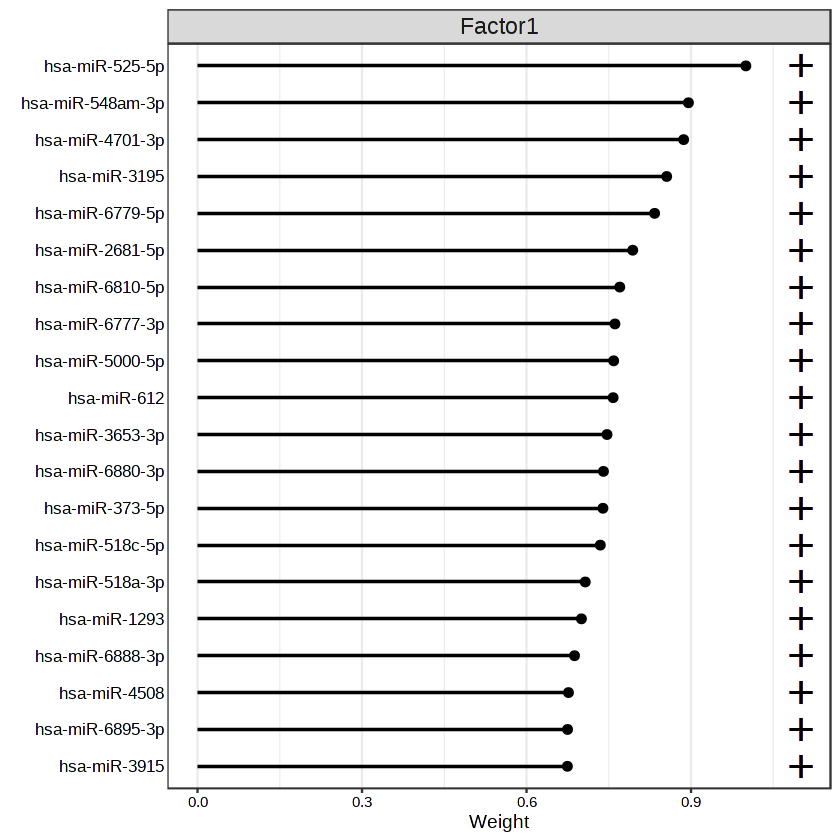

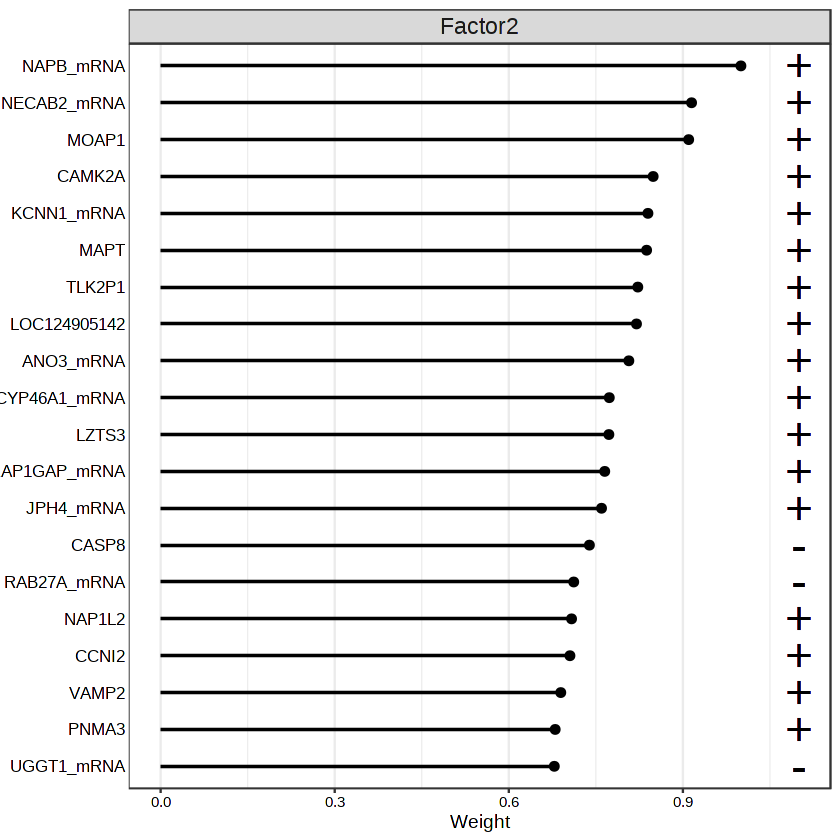

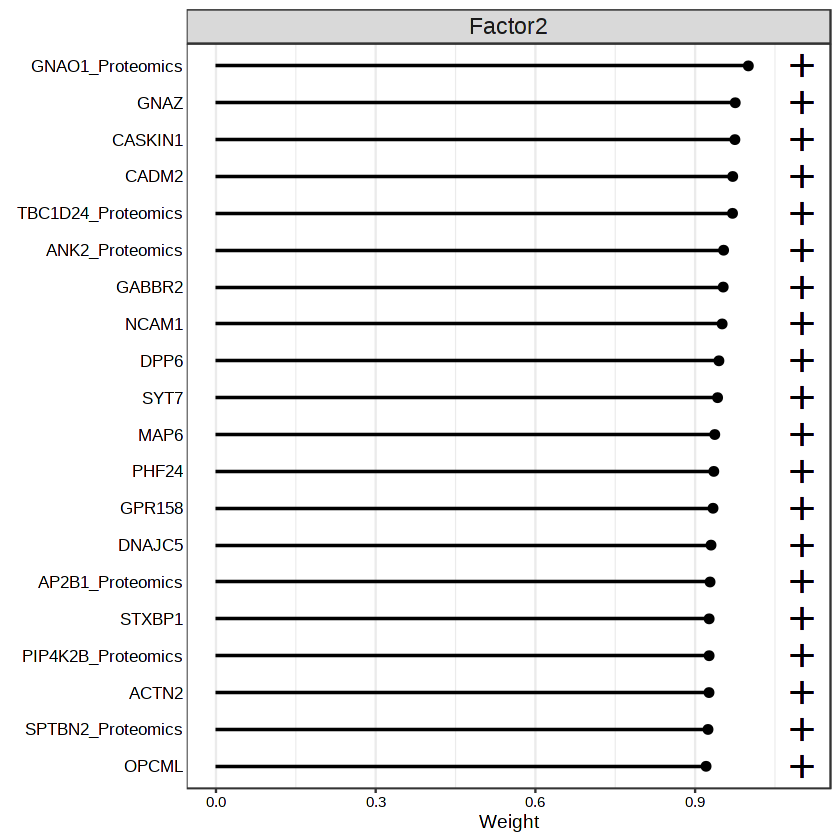

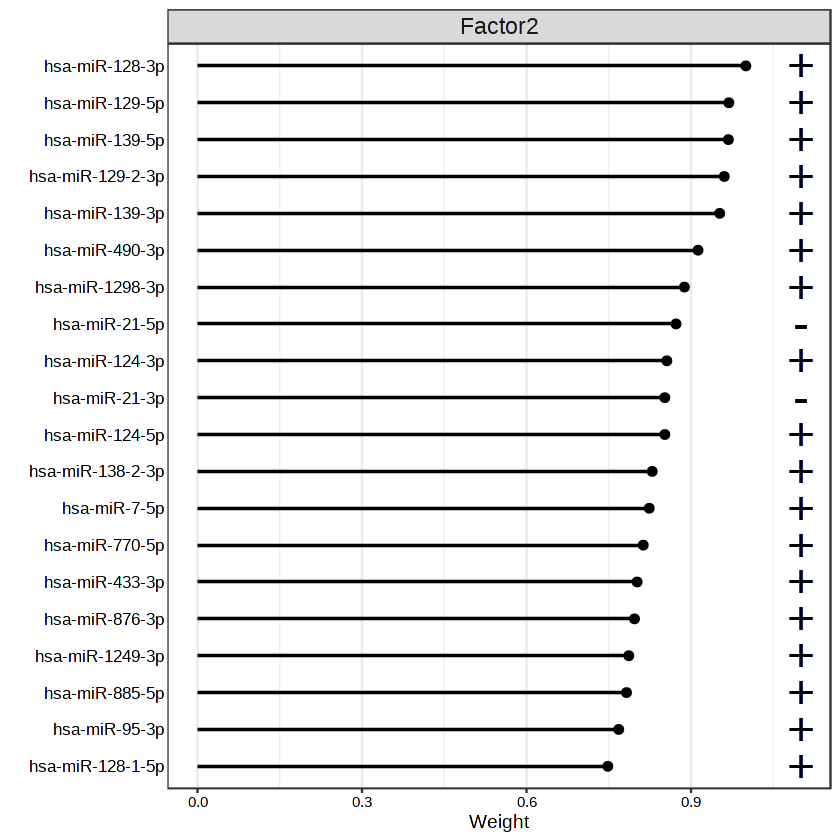

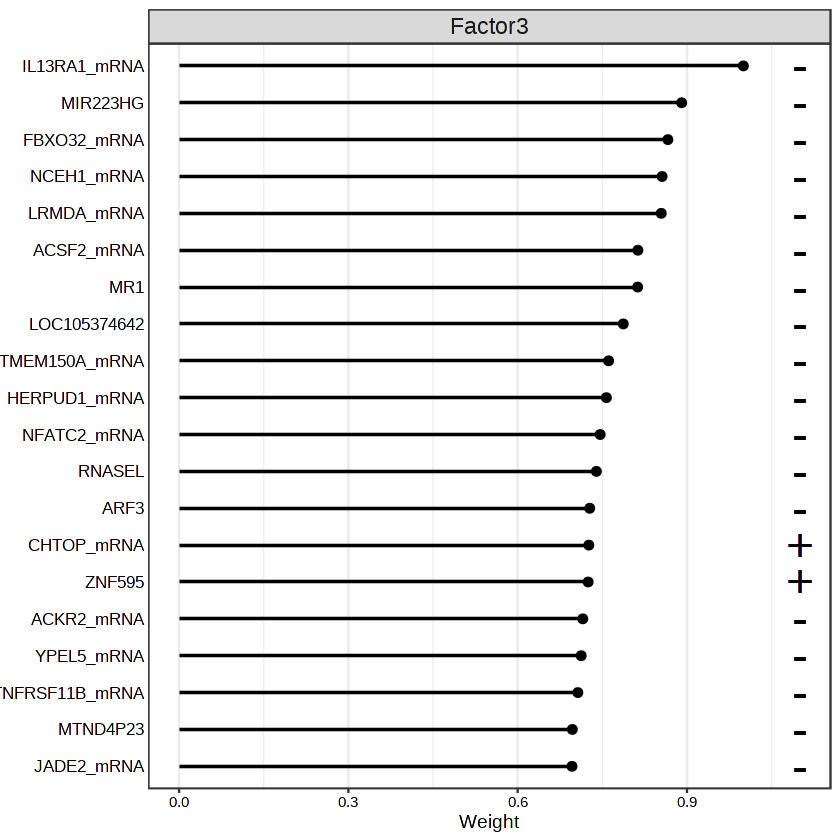

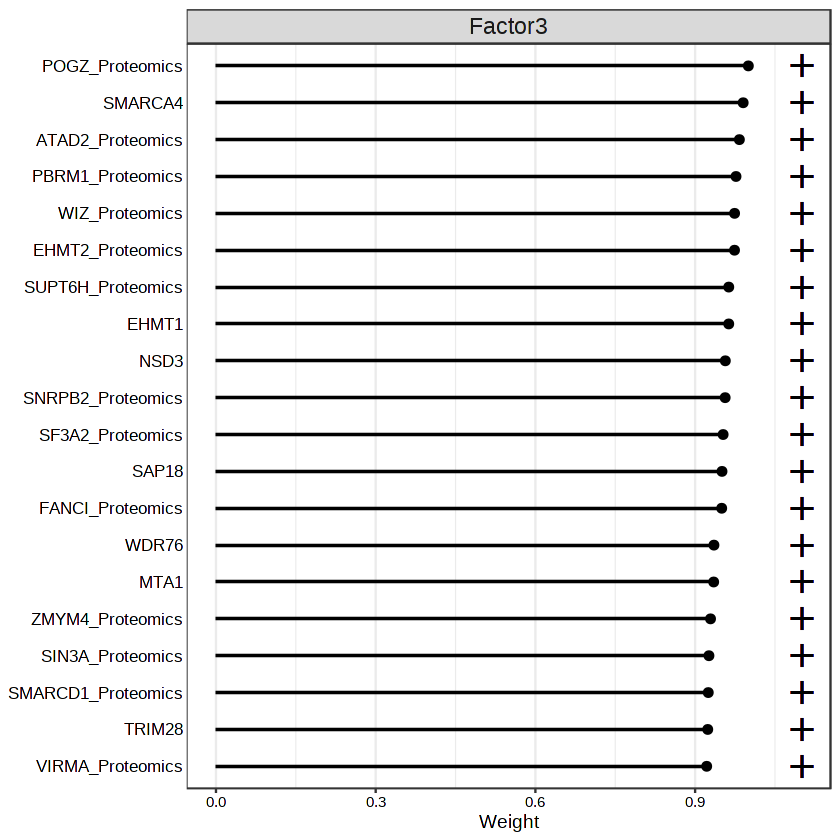

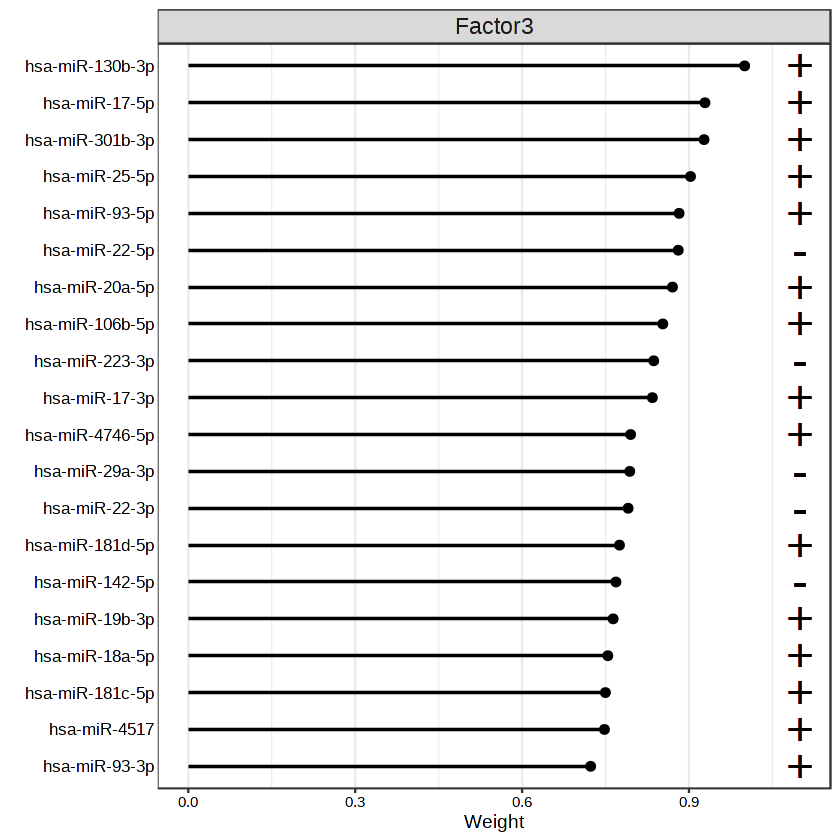

In [ ]:
#Factor values by EGFR status (violin)
plot_factor(MOFAobject, factors = 1:4, color_by = "EGFR_mutation", add_violin = TRUE, dodge = TRUE)

### CELL 25 — Top feature weights per factor (NOTE: singular "factor=", not "factors=")
plot_top_weights(MOFAobject, view = "mRNA",        factor = 1, nfeatures = 20)
plot_top_weights(MOFAobject, view = "Proteomics",  factor = 1, nfeatures = 20)
plot_top_weights(MOFAobject, view = "Methylation", factor = 1, nfeatures = 20)
plot_top_weights(MOFAobject, view = "miRNA",       factor = 1, nfeatures = 20)

plot_top_weights(MOFAobject, view = "mRNA",       factor = 2, nfeatures = 20)
plot_top_weights(MOFAobject, view = "Proteomics", factor = 2, nfeatures = 20)
plot_top_weights(MOFAobject, view = "miRNA",      factor = 2, nfeatures = 20)

plot_top_weights(MOFAobject, view = "mRNA",       factor = 3, nfeatures = 20)
plot_top_weights(MOFAobject, view = "Proteomics", factor = 3, nfeatures = 20)
plot_top_weights(MOFAobject, view = "miRNA",      factor = 3, nfeatures = 20)

In [ ]:
#Extract all weights as a table (for your appendix / supplementary)
weights <- get_weights(MOFAobject, views = "all", factors = 1:3, as.data.frame = TRUE)
top_weights <- weights %>% group_by(view, factor) %>% arrange(desc(abs(value))) %>% slice_head(n = 20)
top_weights

feature,factor,value,view
<fct>,<fct>,<dbl>,<fct>
LOC124901037,Factor1,0.06181831,mRNA
RNA5-8SP,Factor1,0.05914955,mRNA
LOC100500719,Factor1,0.05065749,mRNA
RNU6-228P,Factor1,0.05065749,mRNA
MIR548AA1,Factor1,0.05065749,mRNA
LOC442225,Factor1,0.05065749,mRNA
RNU6-892P,Factor1,0.05065749,mRNA
RPS3AP52,Factor1,0.05065749,mRNA
MIR548D1,Factor1,0.05065749,mRNA


,sample,factor,value,group
,<chr>,<fct>,<dbl>,<chr>
1,C3N-01368,Factor1,13.841366,group1
2,C3N-01505,Factor1,13.662424,group1
3,C3N-00662,Factor1,13.258102,group1
4,C3N-02784,Factor1,-2.775755,group1
5,C3L-00104,Factor1,-2.648633,group1
6,C3L-01046,Factor1,2.072090,group1
7,C3N-02788,Factor1,-2.040192,group1
8,C3N-01815,Factor1,1.817740,group1
9,C3L-01834,Factor1,1.797101,group1


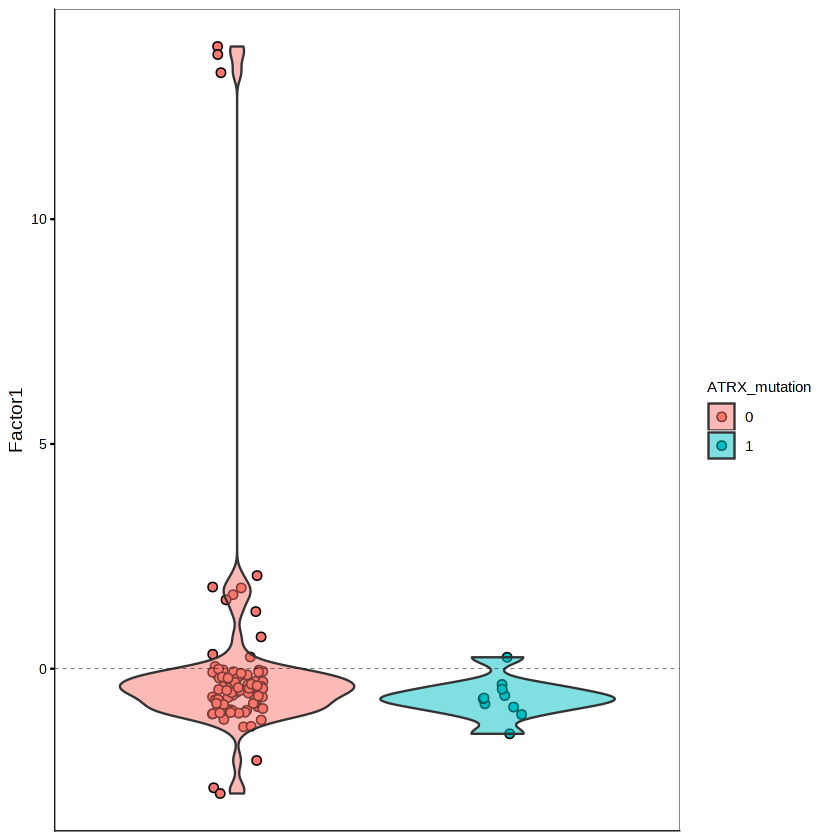

In [ ]:
#Investigate the Factor 1 outlier-sample question
# Factor 1 is almost entirely driven by Methylation (from Cell 22's heatmap).
# Check whether it's driven by a handful of extreme samples (a G-CIMP-like
# hypermethylation signature is real GBM biology -- see write-up) rather than
# a uniform, broadly-shared effect:
Z1 <- get_factors(MOFAobject, factors = 1, as.data.frame = TRUE)
Z1 %>% arrange(desc(abs(value))) %>% head(10)

# Check whether those extreme-Factor-1 samples carry ATRX mutations (co-occurs
# with IDH-mutant / G-CIMP gliomas):
plot_factor(MOFAobject, factors = 1, color_by = "ATRX_mutation", add_violin = TRUE, dodge = TRUE)

Call:
coxph(formula = SurvObject ~ Z)

  n= 87, number of events= 61 
   (9 observations deleted due to missingness)

               coef exp(coef)  se(coef)      z Pr(>|z|)   
ZFactor1   0.145457  1.156568  0.045374  3.206  0.00135 **
ZFactor2  -0.050122  0.951113  0.121020 -0.414  0.67875   
ZFactor3  -0.118658  0.888111  0.153624 -0.772  0.43988   
ZFactor4  -0.185336  0.830825  0.139906 -1.325  0.18526   
ZFactor5  -0.104670  0.900622  0.120468 -0.869  0.38492   
ZFactor6  -0.005202  0.994811  0.161112 -0.032  0.97424   
ZFactor7  -0.037170  0.963512  0.229117 -0.162  0.87112   
ZFactor8   0.214792  1.239604  0.231886  0.926  0.35430   
ZFactor9  -0.329531  0.719261  0.274749 -1.199  0.23038   
ZFactor10  0.252996  1.287878  0.380967  0.664  0.50663   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

          exp(coef) exp(-coef) lower .95 upper .95
ZFactor1     1.1566     0.8646    1.0582     1.264
ZFactor2     0.9511     1.0514    0.7503     1.206
ZFactor3    

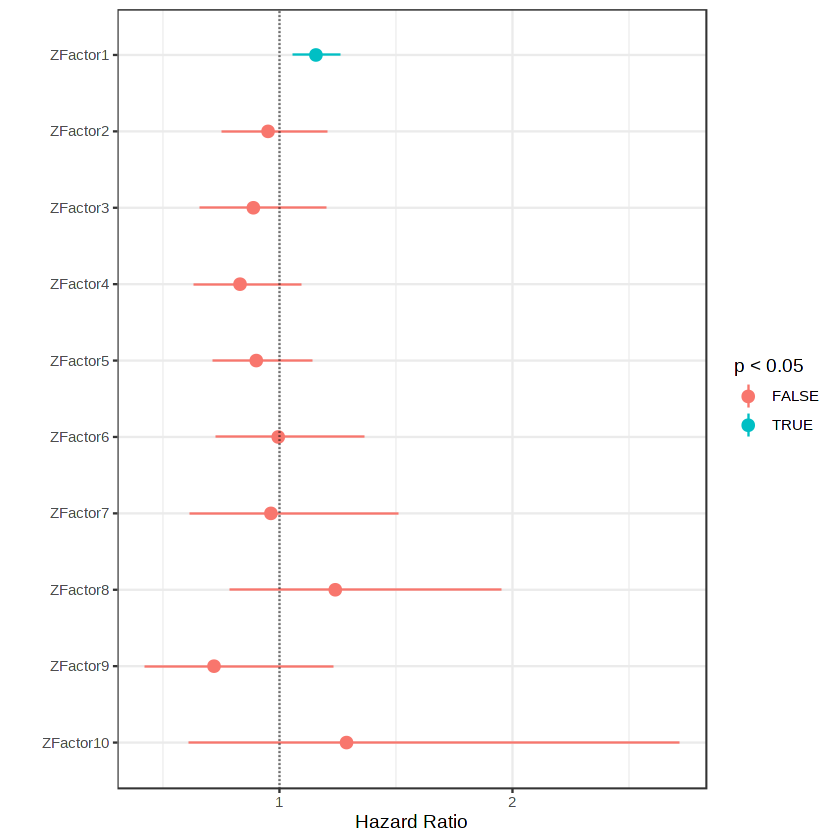

In [ ]:
#Survival: Cox proportional hazards model on the factors
Z <- get_factors(MOFAobject)[[1]]
SurvObject <- Surv(samples_metadata(MOFAobject)$OS_days, samples_metadata(MOFAobject)$OS_event)
fit_cox <- coxph(SurvObject ~ Z)
summary(fit_cox)

s <- summary(fit_cox); coef <- s[["coefficients"]]
df_hr <- data.frame(
  factor = factor(rownames(coef), levels = rev(rownames(coef))),
  p      = coef[, "Pr(>|z|)"],
  hr     = coef[, "exp(coef)"],
  lower  = s[["conf.int"]][, "lower .95"],
  higher = s[["conf.int"]][, "upper .95"]
)
ggplot(df_hr, aes(x = factor, y = hr, ymin = lower, ymax = higher, color = p < 0.05)) +
  geom_pointrange() + coord_flip() +
  geom_hline(yintercept = 1, linetype = "dotted") +
  labs(y = "Hazard Ratio", x = "") + theme_bw()

Enrichment analysis and biological interpretation

In [ ]:
options(repos = c(CRAN = "https://packagemanager.posit.co/cran/__linux__/jammy/latest"))
install.packages(c("ggtangle", "enrichplot"))
BiocManager::install("clusterProfiler", update = FALSE, ask = FALSE)
library(clusterProfiler)
library(enrichplot)
library(multiMiR)
library(org.Hs.eg.db)   # already loaded, needed again here for GO/KEGG gene ID mapping

Installing packages into ‘/content/drive/MyDrive/Colab Notebooks/R_lib’
(as ‘lib’ is unspecified)

Warning message:
“package ‘enrichplot’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”
Warning message in install.packages(c("ggtangle", "enrichplot")):
“installation of package ‘ggtangle’ had non-zero exit status”
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://packagemanager.posit.co/cran/__linux__/jammy/latest

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Installing package(s) 'clusterProfiler'

also installing the dependencies ‘ggtangle’, ‘enrichplot’


Warning message in install.packages(...):
“installation of package ‘ggtangle’ had non-zero exit status”
Warning mess

ERROR: Error in library(clusterProfiler): there is no package called ‘clusterProfiler’


### Alternative for Enrichment: `GOseq`

Given the persistent installation issues with `clusterProfiler` and its dependencies (like `ggtangle` and `enrichplot`) due to compilation errors in this Colab environment, we will switch to an alternative package for Gene Ontology (GO) enrichment: `GOseq`.

`GOseq` is designed for performing GO enrichment analysis, particularly for RNA-seq data, and importantly, it can account for gene length bias, which is a common issue in differential expression studies. While it might not have the same direct KEGG integration as `clusterProfiler`, it provides a reliable method for GO analysis.

First, let's ensure `GOseq` is installed and loaded.

In [ ]:
if (!requireNamespace("GOseq", quietly = TRUE)) BiocManager::install("GOseq", update = FALSE, ask = FALSE)
library(GOseq)

# Ensure 'genomewide.db' is available for gene lengths
if (!requireNamespace("Homo.sapiens", quietly = TRUE)) BiocManager::install("Homo.sapiens", update = FALSE, ask = FALSE)
library(Homo.sapiens)


'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://packagemanager.posit.co/cran/__linux__/jammy/latest

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Installing package(s) 'GOseq'

Warning message:
“package ‘GOseq’ is not available for Bioconductor version '3.23'

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”
Warning message:
“Perhaps you meant ‘goseq’ ?”


ERROR: Error in library(GOseq): there is no package called ‘GOseq’


Now, let's prepare the data for `GOseq` using the RNA-seq DEGs found earlier. `GOseq` requires a vector of differentially expressed genes, and a corresponding vector indicating all genes tested for differential expression, along with their lengths.

In [ ]:
# Get the list of all genes that were tested in the RNA-seq DE analysis
all_genes_rna <- DEGs$Gene

# Get the list of significant genes
sig_genes_rna <- DEGs %>% filter(adj.P.Val < 0.05) %>% pull(Gene)

# Create a binary vector: 1 if gene is significant, 0 otherwise
deff_genes <- as.integer(all_genes_rna %in% sig_genes_rna)
names(deff_genes) <- all_genes_rna

# Get gene lengths (this is crucial for GOseq to correct for length bias)
# Using 'select' from AnnotationDbi to get gene lengths
# For simplicity, we'll use Entrez IDs to get gene lengths. This might require mapping from SYMBOL to ENTREZID first.
# However, `Homo.sapiens` package might have gene length information directly mapped to SYMBOL or ENSEMBL.
# Let's try to get lengths for all tested genes.

gene_lengths <- AnnotationDbi::select(
  Homo.sapiens,
  keys = all_genes_rna,
  columns = c("TXLENGTH"),
  keytype = "SYMBOL"
)

# Average transcript length if multiple are present for a gene
gene_lengths <- gene_lengths %>%
  group_by(SYMBOL) %>%
  summarise(avg_length = mean(TXLENGTH, na.rm = TRUE))

# Filter out NA lengths and match to our `deff_genes`
gene_lengths_filtered <- gene_lengths %>%
  filter(!is.na(avg_length)) %>%
  tibble::deframe() # Convert to named vector

# Ensure `deff_genes` only contains genes for which we have length information
deff_genes_final <- deff_genes[names(deff_genes) %in% names(gene_lengths_filtered)]

# Ensure gene_lengths_filtered is ordered correctly to match deff_genes_final
gene_lengths_final <- gene_lengths_filtered[names(deff_genes_final)]

cat("Number of genes for GOseq analysis:", length(deff_genes_final), "\n")
cat("Number of significant genes:", sum(deff_genes_final), "\n")

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'select': object 'Homo.sapiens' not found


Now we can run the `GOseq` enrichment analysis. First, we need to calculate the probability weighting function (PWF), which accounts for the length bias. Then, we perform the GO enrichment test.

In [ ]:
# Calculate the probability weighting function (PWF)
pwf <- nullp(deff_genes_final, "hg19", "geneSymbol") # Using 'hg19' as an example genome, this might need adjustment

# Perform GO enrichment
GO_results <- goseq(pwf, "hg19", "geneSymbol") # Using 'hg19' as an example genome, this might need adjustment

# Filter and display significant GO terms
sig_GO <- GO_results %>%
  filter(overrepresented_pvalue < 0.05) %>%
  arrange(overrepresented_pvalue)

if (nrow(sig_GO) > 0) {
  cat("Top 20 over-represented GO terms (Biological Process):")
  print(head(sig_GO, 20))
} else {
  cat("No significant over-represented GO terms found.\n")
}

ERROR: Error in nullp(deff_genes_final, "hg19", "geneSymbol"): could not find function "nullp"


### Exporting Gene Lists for External Enrichment Analysis

Given the persistent issues with installing and running R enrichment packages in this environment, we will now export the lists of significant differentially expressed genes, proteins, methylated genes, and miRNAs. These lists can then be used with external web-based enrichment tools (e.g., DAVID, Enrichr, Metascape) for Gene Ontology (GO) and pathway analysis.

Each list will be saved as a separate CSV file for easy download and upload to these platforms.

In [ ]:
# Extract significant gene lists

# RNA-seq DEGs
sig_genes_rna <- DEGs %>% filter(adj.P.Val < 0.05) %>% pull(Gene)
write.csv(sig_genes_rna, "significant_RNA_DEGs.csv", row.names = FALSE)
cat("Exported", length(sig_genes_rna), "significant RNA-seq DEGs to significant_RNA_DEGs.csv\n")

# Proteomics DEGs
sig_genes_prot <- DE_proteins %>% filter(adj.P.Val < 0.05) %>% pull(Gene)
write.csv(sig_genes_prot, "significant_Proteomics_DEGs.csv", row.names = FALSE)
cat("Exported", length(sig_genes_prot), "significant Proteomics DEGs to significant_Proteomics_DEGs.csv\n")

# Methylation DMGs
sig_genes_meth <- DMGs %>% filter(adj.P.Val < 0.05) %>% pull(Gene)
write.csv(sig_genes_meth, "significant_Methylation_DMGs.csv", row.names = FALSE)
cat("Exported", length(sig_genes_meth), "significant Methylation DMGs to significant_Methylation_DMGs.csv\n")

# miRNA DEGs
sig_mirnas <- DE_miRNAs %>% filter(adj.P.Val < 0.05) %>% pull(Gene)
write.csv(sig_mirnas, "significant_miRNA_DEGs.csv", row.names = FALSE)
cat("Exported", length(sig_mirnas), "significant miRNA DEGs to significant_miRNA_DEGs.csv\n")

# Note: Due to multiMiR installation issues, predicted miRNA target genes are not directly available.
# You would need to use an external tool to predict targets from these significant miRNAs if desired.

cat("All significant gene lists have been exported. You can find them in your Colab files browser or Google Drive (if mounted) and use them for external enrichment analysis.\n")

Exported 2 significant RNA-seq DEGs to significant_RNA_DEGs.csv
Exported 0 significant Proteomics DEGs to significant_Proteomics_DEGs.csv
Exported 0 significant Methylation DMGs to significant_Methylation_DMGs.csv
Exported 0 significant miRNA DEGs to significant_miRNA_DEGs.csv
All significant gene lists have been exported. You can find them in your Colab files browser or Google Drive (if mounted) and use them for external enrichment analysis.


In [ ]:
#SYSTEMATIC FACTOR SCREENING (do this BEFORE deep-diving any factor)
r2 <- get_variance_explained(MOFAobject, as.data.frame = TRUE)$r2_per_factor
colnames(r2)   # check actual column names first -- typically factor, view, value, group

# Breadth: how many views does each factor explain >2% of variance in?
r2_wide <- r2 %>%
  tidyr::pivot_wider(id_cols = factor, names_from = view, values_from = value)
r2_wide$n_views_over_2pct <- rowSums(r2_wide[,-1] > 2, na.rm = TRUE)

# Cox model significance per factor (fit_cox is from Part 1, Cell 28)
cox_summary <- summary(fit_cox)$coefficients
cox_df <- data.frame(
  factor = gsub("^Z", "", rownames(cox_summary)),   # coxph names them "ZFactor1" -- strip the "Z"
  cox_p  = cox_summary[, "Pr(>|z|)"],
  cox_HR = cox_summary[, "exp(coef)"]
)

factor_screen <- r2_wide %>%
  dplyr::left_join(cox_df, by = "factor") %>%
  dplyr::arrange(cox_p)

print(factor_screen, width = Inf)
# READ THIS TABLE FIRST. Prioritize factors with (a) n_views_over_2pct >= 2
# AND (b) cox_p < 0.05 for deep-dive interpretation below. Report the others
# briefly too (e.g. "Factor X explained variance in only one view and was not
# significantly associated with survival") -- that's honest, complete reporting,
# not a gap in your analysis.

[1] "group"  "view"   "factor" "value"

# A tibble: 10 × 9
   factor      mRNA Proteomics Methylation  miRNA Mutations n_views_over_2pct
   <chr>      <dbl>      <dbl>       <dbl>  <dbl>     <dbl>             <dbl>
 1 Factor1  0.452      0.0261     73.7     0.981    0.00683                 1
 2 Factor4  0.199      9.72        0.00186 0.255    0.00701                 1
 3 Factor9  0.595      0.0419      1.95    0.366    0.00678                 0
 4 Factor8  0.836      0.0143      1.61    0.534    0.00809                 0
 5 Factor5  1.63       4.41        0.238   3.03     0.00942                 2
 6 Factor3  2.95       8.90        0.0408  3.17     0.00564                 3
 7 Factor10 0.00853    0.00535     1.52    0.0222   0.00546                 0
 8 Factor2  2.39      12.7         0.0695  3.79     0.00615                 3
 9 Factor7  0.563      0.0116      3.26    0.483    0.00924                 1
10 Factor6  0.361      0.0171      4.27    0.189    0.00646                 1
     cox_p cox_HR
     <dbl>  <dbl>
 1 0.0013

In [ ]:
#RNA: GO + KEGG enrichment on DEGs
sig_genes_rna <- DEGs %>% filter(adj.P.Val < 0.05) %>% pull(Gene)
length(sig_genes_rna)

# Map gene SYMBOLs to ENTREZ IDs (clusterProfiler/KEGG require Entrez, not symbols)
entrez_rna <- bitr(sig_genes_rna, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)

go_rna <- enrichGO(gene = entrez_rna$ENTREZID, OrgDb = org.Hs.eg.db,
                    ont = "BP", pAdjustMethod = "BH",
                    pvalueCutoff = 0.05, qvalueCutoff = 0.2, readable = TRUE)
kegg_rna <- enrichKEGG(gene = entrez_rna$ENTREZID, organism = "hsa",
                        pAdjustMethod = "BH", pvalueCutoff = 0.05)

if (!is.null(go_rna)   && nrow(go_rna@result)   > 0) dotplot(go_rna,   showCategory = 15, title = "RNA DEGs -- GO Biological Process")
if (!is.null(kegg_rna) && nrow(kegg_rna@result) > 0) dotplot(kegg_rna, showCategory = 15, title = "RNA DEGs -- KEGG pathways")

[1] 2

ERROR: Error in bitr(sig_genes_rna, fromType = "SYMBOL", toType = "ENTREZID", : could not find function "bitr"


In [ ]:
# Check if clusterProfiler is installed
"clusterProfiler" %in% rownames(installed.packages())

[1] FALSE

In [ ]:
#Proteomics: GO + KEGG enrichment on DE proteins
sig_genes_prot <- DE_proteins %>% filter(adj.P.Val < 0.05) %>% pull(Gene)
length(sig_genes_prot)

if (length(sig_genes_prot) >= 3) {   # enrichment needs a minimally useful list size
  entrez_prot <- bitr(sig_genes_prot, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
  go_prot   <- enrichGO(gene = entrez_prot$ENTREZID, OrgDb = org.Hs.eg.db, ont = "BP",
                         pAdjustMethod = "BH", pvalueCutoff = 0.05, qvalueCutoff = 0.2, readable = TRUE)
  kegg_prot <- enrichKEGG(gene = entrez_prot$ENTREZID, organism = "hsa", pAdjustMethod = "BH", pvalueCutoff = 0.05)
  if (!is.null(go_prot)   && nrow(go_prot@result)   > 0) dotplot(go_prot,   showCategory = 15, title = "DE Proteins -- GO Biological Process")
  if (!is.null(kegg_prot) && nrow(kegg_prot@result) > 0) dotplot(kegg_prot, showCategory = 15, title = "DE Proteins -- KEGG pathways")
} else {
  cat("Too few significant proteins (", length(sig_genes_prot), ") for a reliable enrichment test.\n")
  cat("This itself is a reportable result -- state the count and move on rather than force a test.\n")
}

In [ ]:
#Methylation: genes affected + GO/KEGG enrichment
# LinkedOmics methylation data is already GENE-LEVEL (aggregated from CpG probes to one
# score per gene), so DMGs' rownames/Gene column ARE the affected genes directly --
# no probe-to-gene mapping step is needed here (unlike raw 450K array data).
sig_genes_meth <- DMGs %>% filter(adj.P.Val < 0.05) %>% pull(Gene)
length(sig_genes_meth)

# IMPORTANT CAVEAT for your report: whether hyper- vs hypo-methylation activates or
# silences a gene depends on WHERE on the gene it occurs. Promoter/TSS methylation
# is classically associated with gene SILENCING; gene-body methylation is often
# POSITIVELY correlated with expression. LinkedOmics' gene-level score does not tell
# you which region was measured, so state this as a limitation rather than assuming
# "hypermethylated = silenced" outright.

if (length(sig_genes_meth) >= 3) {
  entrez_meth <- bitr(sig_genes_meth, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
  go_meth   <- enrichGO(gene = entrez_meth$ENTREZID, OrgDb = org.Hs.eg.db, ont = "BP",
                         pAdjustMethod = "BH", pvalueCutoff = 0.05, qvalueCutoff = 0.2, readable = TRUE)
  kegg_meth <- enrichKEGG(gene = entrez_meth$ENTREZID, organism = "hsa", pAdjustMethod = "BH", pvalueCutoff = 0.05)
  if (!is.null(go_meth)   && nrow(go_meth@result)   > 0) dotplot(go_meth,   showCategory = 15, title = "Differentially Methylated Genes -- GO BP")
  if (!is.null(kegg_meth) && nrow(kegg_meth@result) > 0) dotplot(kegg_meth, showCategory = 15, title = "Differentially Methylated Genes -- KEGG")
} else {
  cat("Too few significant DMGs (", length(sig_genes_meth), ") for reliable enrichment.\n")
}

In [ ]:
#miRNA: predicted target genes + enrichment on those targets
sig_mirnas <- DE_miRNAs %>% filter(adj.P.Val < 0.05) %>% pull(Gene)   # "Gene" column here holds miRNA names
length(sig_mirnas)

if (length(sig_mirnas) >= 1) {
  library(multiMiR)
  # Query validated (miRTarBase/TarBase) + predicted (TargetScan/miRDB/PicTar) targets.
  # This makes a live query to an external database -- may take a minute, and can
  # occasionally time out on Colab; if it fails, see the fallback note below.
  mir_targets <- get_multimir(mirna = sig_mirnas, summary = TRUE,
                               table = "validated")   # start with validated only -- higher confidence, smaller list

  target_genes <- unique(mir_targets@data$target_symbol)
  cat("Validated target genes found for", length(sig_mirnas), "significant miRNAs:", length(target_genes), "\n")

  if (length(target_genes) >= 3) {
    entrez_mir <- bitr(target_genes, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
    go_mir   <- enrichGO(gene = entrez_mir$ENTREZID, OrgDb = org.Hs.eg.db, ont = "BP",
                          pAdjustMethod = "BH", pvalueCutoff = 0.05, qvalueCutoff = 0.2, readable = TRUE)
    kegg_mir <- enrichKEGG(gene = entrez_mir$ENTREZID, organism = "hsa", pAdjustMethod = "BH", pvalueCutoff = 0.05)
    if (!is.null(go_mir)   && nrow(go_mir@result)   > 0) dotplot(go_mir,   showCategory = 15, title = "Predicted miRNA Target Genes -- GO BP")
    if (!is.null(kegg_mir) && nrow(kegg_mir@result) > 0) dotplot(kegg_mir, showCategory = 15, title = "Predicted miRNA Target Genes -- KEGG")
  }
} else {
  cat("No significant DE miRNAs -- target prediction has nothing to run on.\n")
  cat("This is a legitimate result to report, not a failure.\n")
}
# FALLBACK if multiMiR times out or errors: report your top 5-10 significant miRNAs
# by name and log2FC, and discuss 1-2 of the most well-documented ones qualitatively
# using known literature (e.g. miR-21 is a validated GBM oncomiR -- see earlier
# conversation). This is a legitimate, honest substitute if the live database query fails.

In [ ]:
#MOFA-level interpretation: does factor GSEA agree with your DE lists?
# Cross-check: genes appearing BOTH in a MOFA factor's top weights AND in the
# independent (supervised) DEG list are convergent evidence -- the same biology
# found two different ways. Do this for whichever factor(s) passed Cell 30's screen:
FACTOR_TO_CHECK <- 2   # <-- replace with your top-screened factor number from Cell 30

factor_weights <- get_weights(MOFAobject, views = "mRNA", factors = FACTOR_TO_CHECK, as.data.frame = TRUE)
top_factor_genes <- factor_weights %>% arrange(desc(abs(value))) %>% slice_head(n = 50) %>% pull(feature)

overlap <- intersect(top_factor_genes, sig_genes_rna)
cat("Factor", FACTOR_TO_CHECK, "top-50 mRNA weights overlapping with RNA DEGs:", length(overlap), "\n")
print(overlap)